In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


from zodiax.optimisation import sgd, adam
from scipy.ndimage import binary_dilation

import amigo
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

source = "NGC1068"
data_path = os.path.join(morgana, f"snert/max/data/JWST/{source}/calslope/")
uncal_path = os.path.join(morgana, f"snert/max/data/JWST/{source}/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F380M",
    # "F430M",
    "F480M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    if not bool(file[0].header["IS_PSF"]):
        # badpix = np.array(file["BADPIX"].data, dtype=bool)
        # im = np.array(file["SLOPE"].data.sum(0))
        # im = np.where(badpix, np.nan, im)
        # mask = binary_dilation(im == np.nanmax(im), iterations=2)
        # file["BADPIX"].data += mask.astype(int)
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

dorito.misc.truncate_files(sci_files, 4)

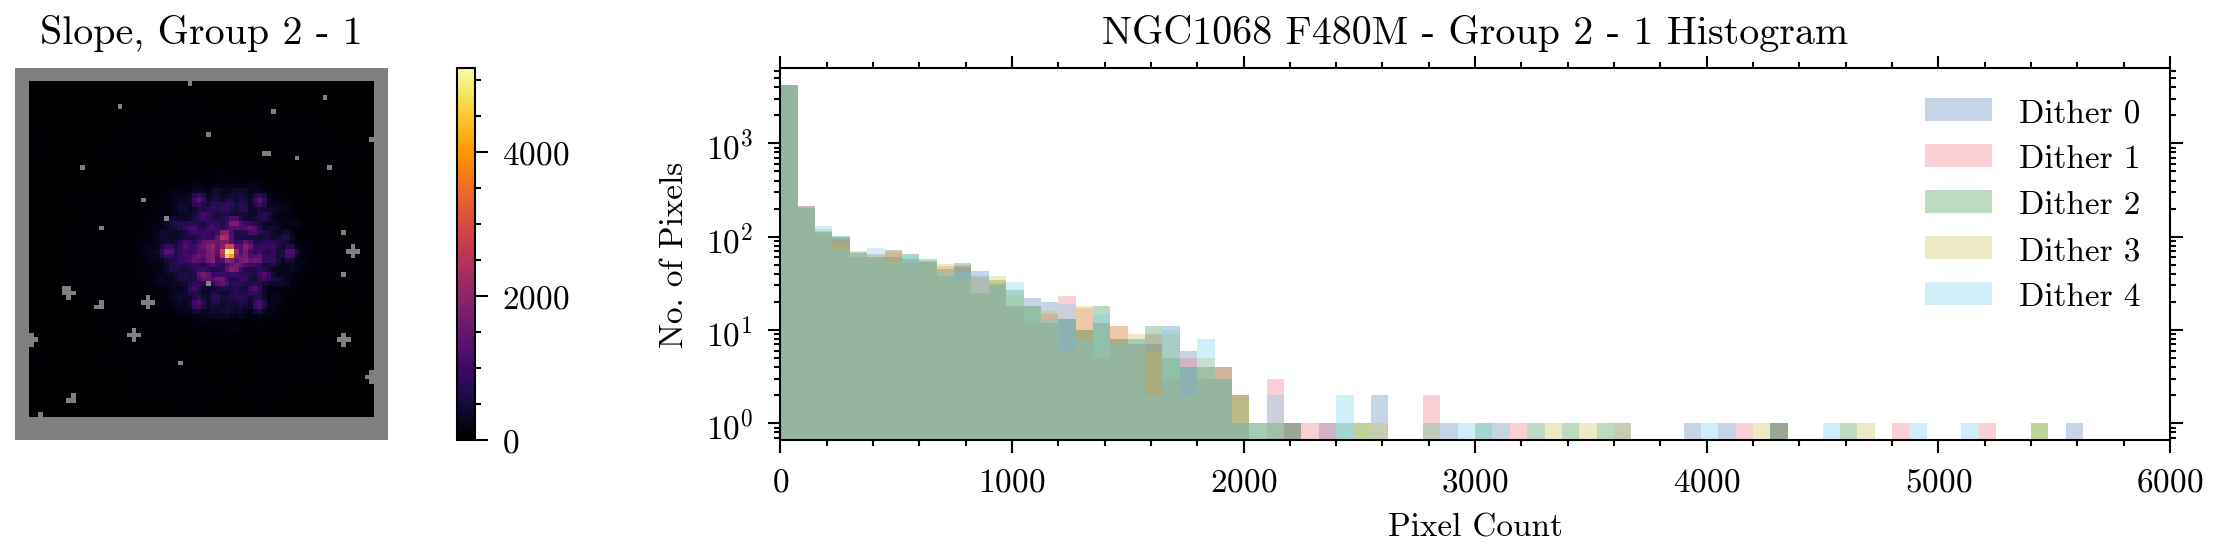

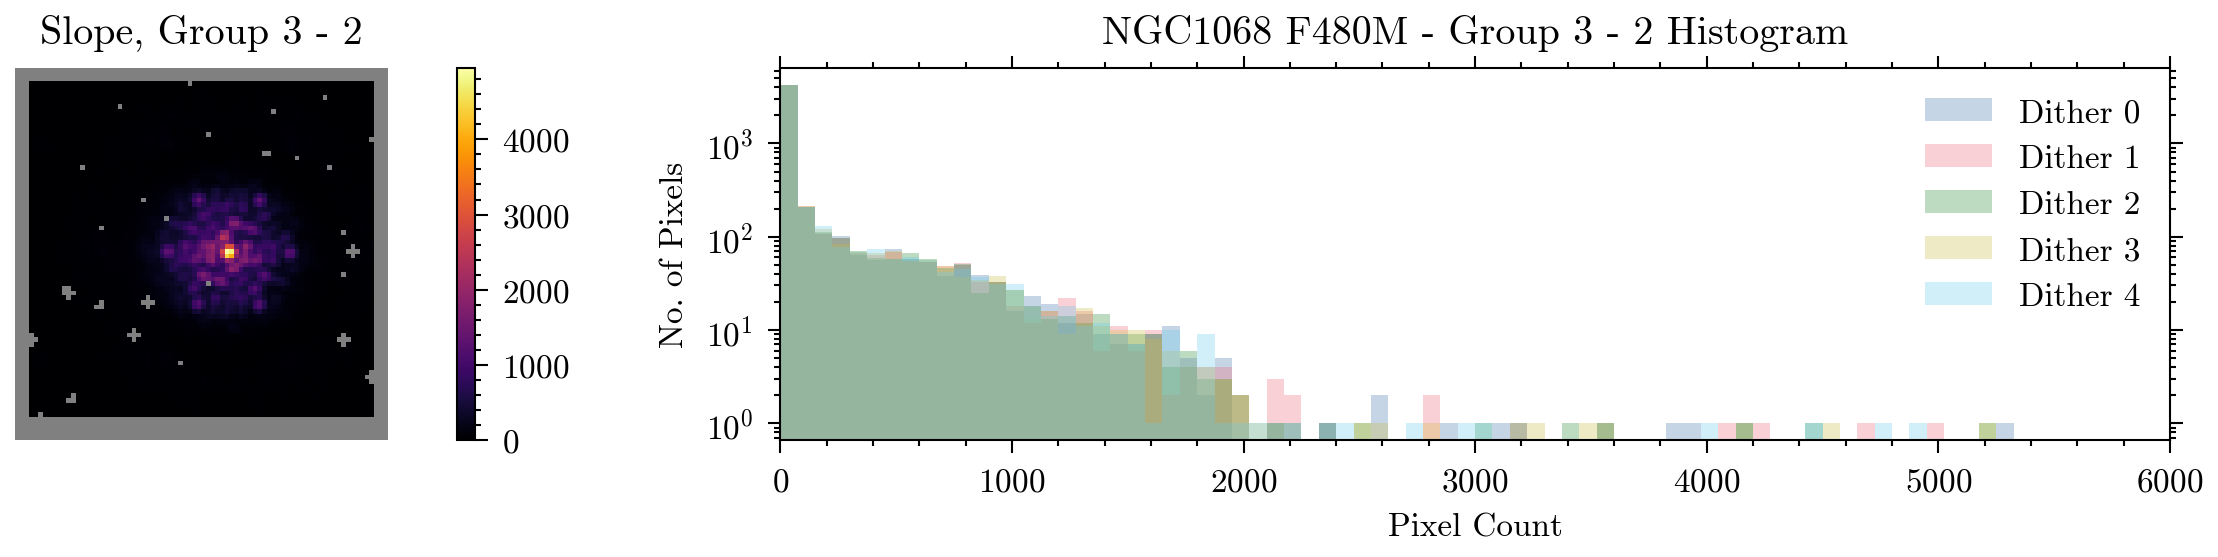

In [4]:
for filt in FILTERS:

    for file in sci_files:
        if file[0].header["FILTER"] == filt:
            ramp = np.array(file["SLOPE"].data)
            break

    for g in range(1, 30):

        if g >= ramp.shape[0]:
            break

        fig, ax = plt.subplots(1, 2, figsize=(10, 2))

        d = 0
        for file in sci_files:
            if file[0].header["FILTER"] != filt:
                continue

            if g >= ramp.shape[0]:
                break_flag = True
                break
            ramp = np.array(file["SLOPE"].data)

            badpix = np.array(file["BADPIX"].data, dtype=bool)
            group = np.where(badpix, np.nan, ramp[g, ...])

            ax[1].hist(
                group.flatten(),
                range=(0, 6000),
                # range=(0, 2**16),
                bins=80,
                log=True,
                alpha=0.3,
                label=f"Dither {d}",
            )

            d += 1

        c = ax[0].imshow(group, inferno)  # just do the last one
        fig.colorbar(c, ax=ax[0])
        ax[0].axis("off")
        ax[0].set_title(f"Slope, Group {g+1} - {g}")
        ax[1].set_title(f"NGC1068 {filt} - Group {g+1} - {g} Histogram")
        # ax[1].axvline(3e4, c="r")
        # ax[1].axvline(2**16, c="k")
        ax[1].set_xlabel("Pixel Count")
        ax[1].set_ylabel("No. of Pixels")
        # ax[1].set(xlim=(0, 2**16))
        ax[1].set(xlim=(0, 6000))
        ax[1].legend()
        plt.tight_layout()
        # plt.savefig(
        #     os.path.join(
        #         output_path + "slope_counts/",
        #         f"slope_ngc1068_{filt}_group_{g:02d}.png",
        #     ),
        #     dpi=300,
        # )
        # plt.close(fig)
        plt.show()

In [5]:
# dorito.plotting.create_gif_from_dir(
#     os.path.join(output_path + "slope_counts/"),
#     name="ngc1068_slope_counts.gif",
#     duration=300,
# )

In [6]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}'
    )

    t0 = t


------------------------------

NGC1068 F480M, Dither 1/5, Roll 273.0deg, 2.3min, 2024-09-16 22:09:19.803, Groups: 20, Ints: 91
NGC1068 F480M, Dither 2/5, Roll 273.0deg, 2.3min, 2024-09-16 22:12:17.915, Groups: 20, Ints: 91
NGC1068 F480M, Dither 3/5, Roll 273.0deg, 2.3min, 2024-09-16 22:15:16.219, Groups: 20, Ints: 91
NGC1068 F480M, Dither 4/5, Roll 273.0deg, 2.3min, 2024-09-16 22:18:15.483, Groups: 20, Ints: 91
NGC1068 F480M, Dither 5/5, Roll 273.0deg, 2.3min, 2024-09-16 22:21:13.595, Groups: 20, Ints: 91
HD 228337 F480M, Dither 1/5, Roll 266.8deg, 0.8min, 2024-09-16 23:43:14.381, Groups: 6, Ints: 103
HD 228337 F480M, Dither 2/5, Roll 266.8deg, 0.8min, 2024-09-16 23:44:42.509, Groups: 6, Ints: 103
HD 228337 F480M, Dither 3/5, Roll 266.8deg, 0.8min, 2024-09-16 23:46:10.573, Groups: 6, Ints: 103
HD 228337 F480M, Dither 4/5, Roll 266.8deg, 0.8min, 2024-09-16 23:47:38.573, Groups: 6, Ints: 103
HD 228337 F480M, Dither 5/5, Roll 266.8deg, 0.8min, 2024-09-16 23:49:06.637, Groups: 6, Ints: 1

/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [7]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

cal_exposures = [amigo.model_fits.SplineVisFit(file) for file in cal_files[0:1]]
sci_exposures = [amigo.model_fits.SplineVisFit(file) for file in sci_files[0:1]]
exposures = cal_exposures + sci_exposures

model = amigo.core_models.AmigoModel(
    exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=load_dict(cache + "calibration.npy"),
)

exposures = sci_exposures

In [8]:
from dLux import utils as dlu
from amigo.misc import interp
import numpy as onp
from scipy.ndimage import center_of_mass


def rotate(distribution, parang, clip=True):
    """
    Rotate the distribution by the parallactic angle.
    This method rotates the distribution using the dLux utility functions.
    Args:
        distribution: The distribution of the resolved source.
        clip: If True, clips the distribution to enforce positivity.
    Returns:
        Array: The rotated distribution, optionally clipped to enforce positivity.
    """
    knots = dlu.pixel_coords(distribution.shape[0], 1.0)
    samps = dlu.rotate_coords(knots, dlu.deg2rad(parang))

    distribution = interp(
        distribution,
        knots,
        samps,
        method="linear",
    )

    # clipping to enforce positivity
    if clip:
        return np.clip(distribution, min=0.0, max=None)

    return distribution


def centre_image(arr, center=None, extra=(0, 0)):
    """
    Shift a 2D array so that its phase center is at the origin (top-left corner),
    using the Fourier shift theorem. JAX-only version (no jax.scipy).

    Parameters:
        arr (np.ndarray): 2D input array (real or complex).
        center (tuple or None): (y, x) coordinates of the current center. If None, uses intensity centroid.

    Returns:
        np.ndarray: Shifted complex array.
    """
    npix = arr.shape[0]

    # Step 1: Compute intensity centroid if center not given
    if center is None:
        center = np.array(center_of_mass(onp.array(arr)))

    knots = dlu.pixel_coords(npix, npix)
    samps = dlu.translate_coords(knots, npix / 2 - center + np.array(extra))

    return interp(
        arr,
        knots,
        samps,
        method="linear",
    )

(np.float64(74.6978344498359), np.float64(74.19285994215998))
(np.float64(76.00497450767591), np.float64(74.99502549232409))


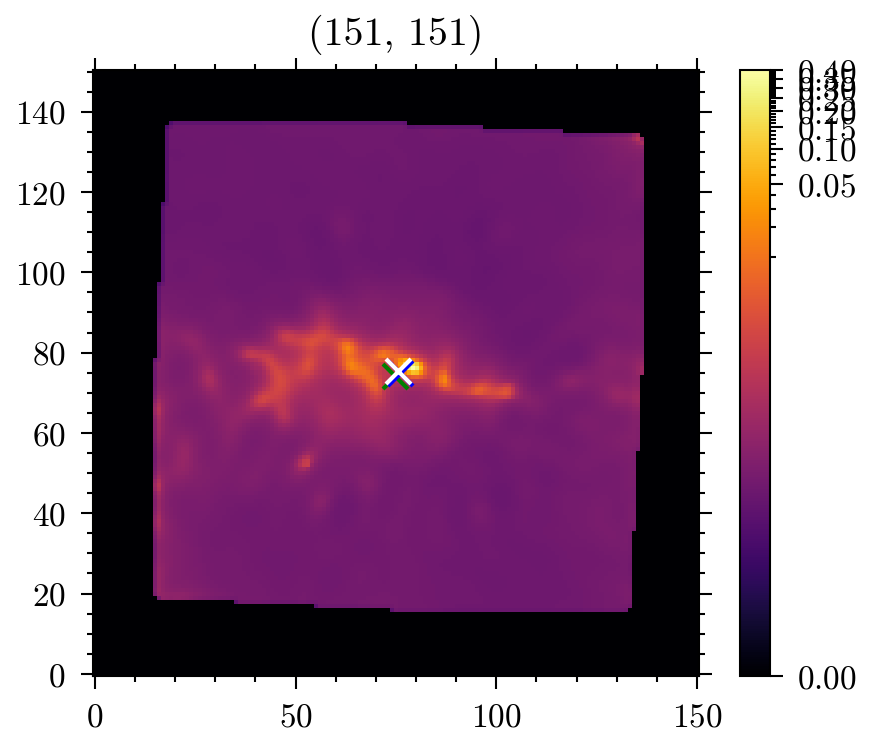

In [9]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

fit_params = load_dict(output_path + "allgoodrun_params.npy")
params = model.params
for p in ["fluxes", "aberrations", "positions", "spectra"]:
    if p in fit_params:
        params[p] = fit_params[p].copy()

mdoel = model.set("params", params)


init_dist = 10 ** fit_params["log_dist"]["F480M"]
init_dist = rotate(init_dist, sci_exposures[0].parang)

init_dist = np.pad(init_dist, 15)
# init_dist /= init_dist.sum()
O1 = center_of_mass(onp.array(init_dist))
print(O1)
init_dist = centre_image(
    init_dist,
    # center=np.array(np.unravel_index(np.argmax(init_dist), init_dist.shape)),
)

O2 = center_of_mass(onp.array(init_dist))
print(O2)

# init_dist *= dlu.soft_circle(dlu.nd_coords(init_dist.shape), 55, 5)
# print(init_dist)
plt.imshow(init_dist, inferno, norm=mpl.colors.PowerNorm(0.1))
plt.colorbar()
plt.scatter(*O1, marker="x", c="green")
plt.scatter(*O2, marker="x", c="blue")
plt.scatter(*np.array(init_dist.shape) / 2, marker="x", c="white")
plt.title(init_dist.shape)
plt.show()

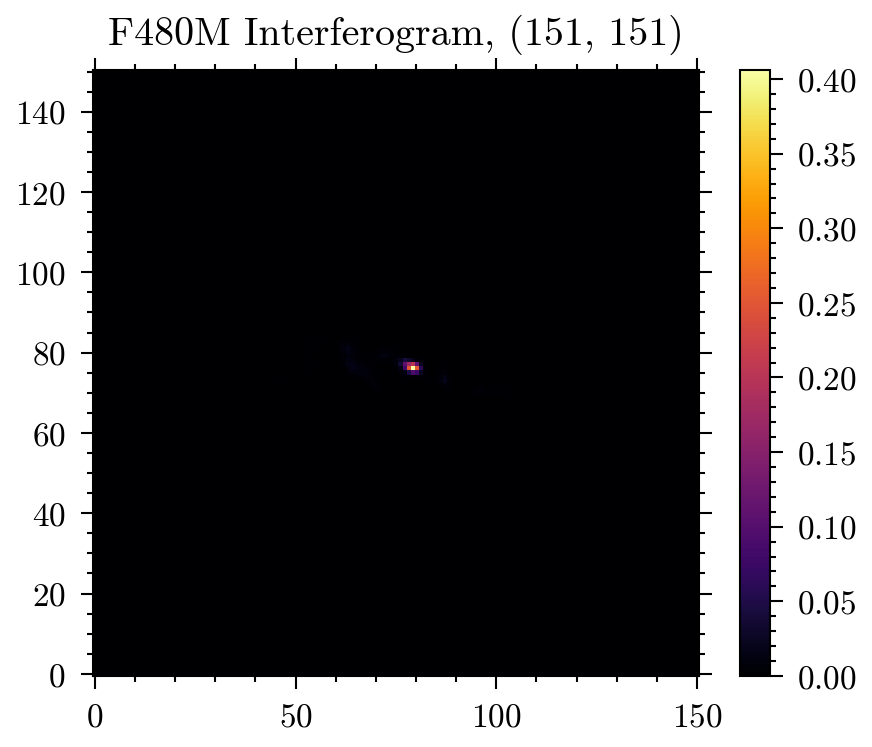

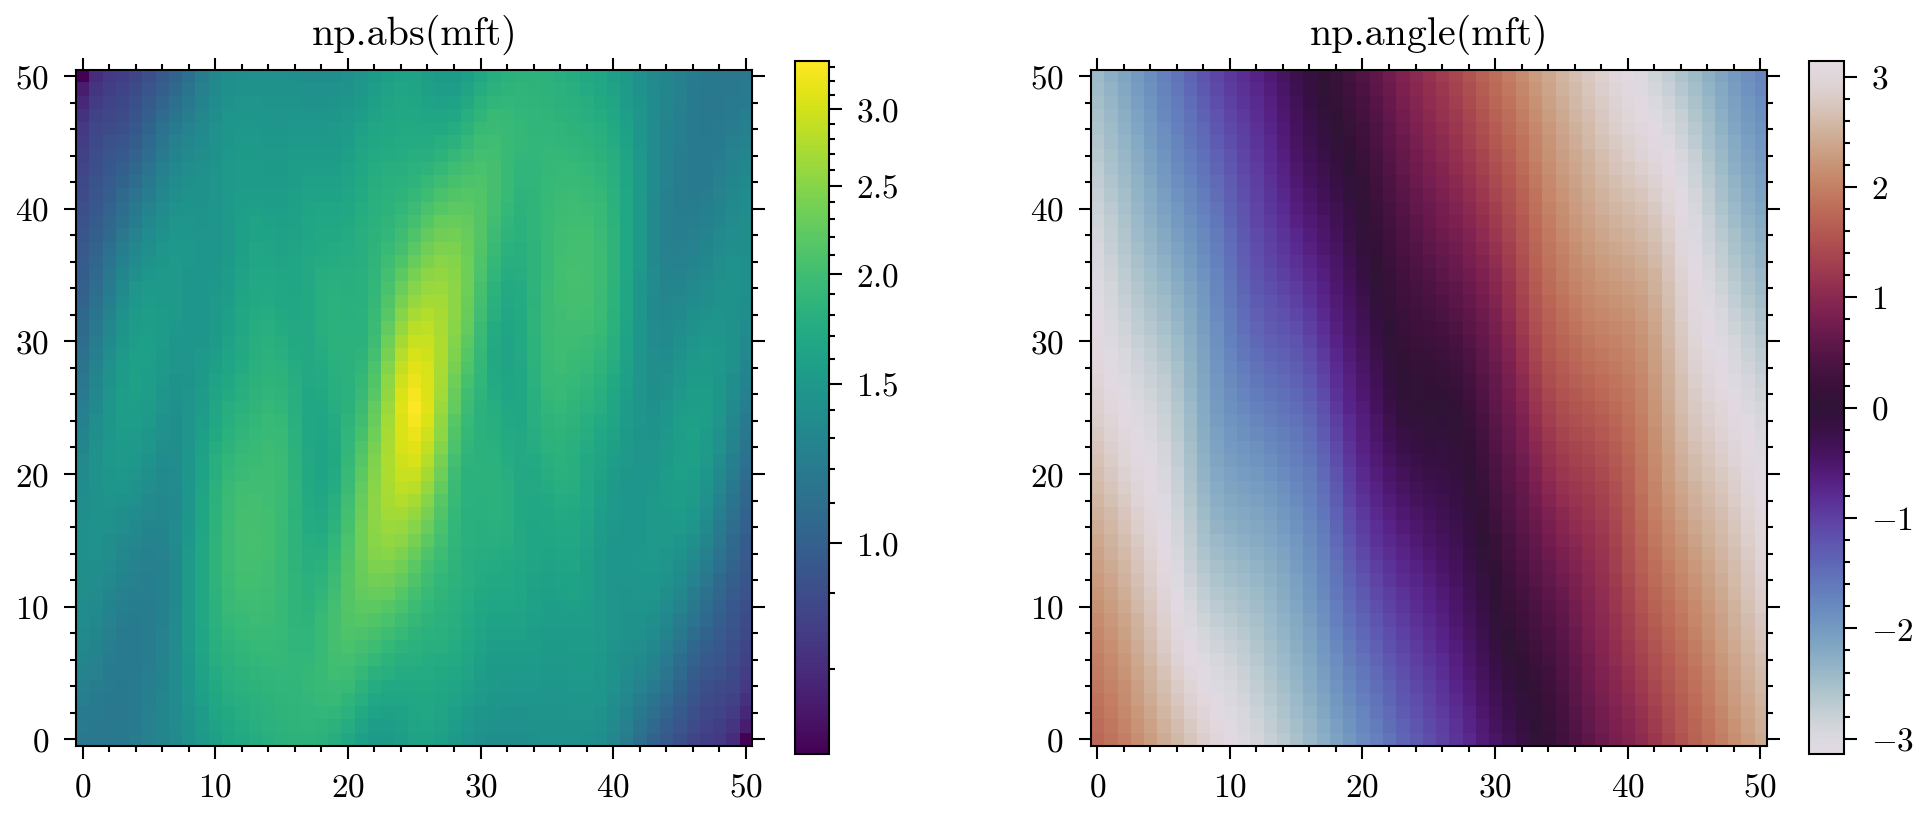

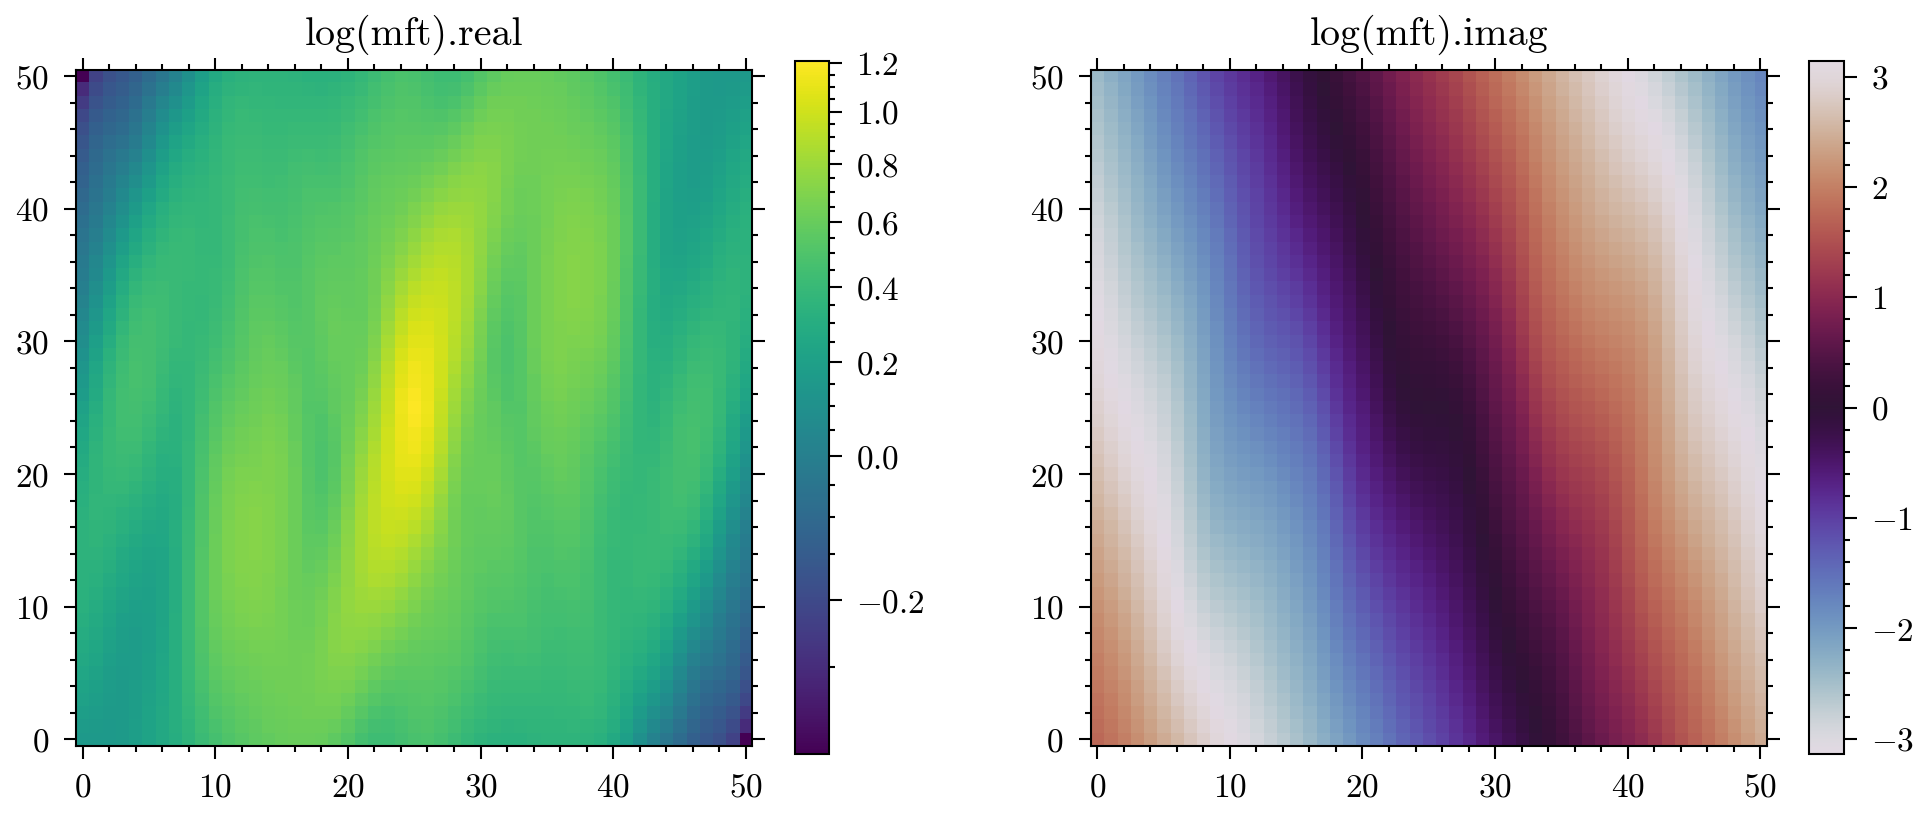

In [10]:
from dLux import utils as dlu
from scipy.interpolate import griddata
import numpy as onp
import jax.numpy as np


def interpolate_nans_2d_jnp(array, method="linear"):

    array = onp.array(array)
    x, y = onp.indices(array.shape)
    valid_mask = ~onp.isnan(array)

    filled = array.copy()
    filled[~valid_mask] = griddata(
        (x[valid_mask], y[valid_mask]),
        array[valid_mask],
        (x[~valid_mask], y[~valid_mask]),
        method=method,
    )

    return np.array(filled)


optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)
otf = np.load("files/otf_support.npy")

for exp in exposures:
    if exp.calibrator:
        continue

    filt = model.filters[exp.filter]
    wavel = np.dot(filt[0], filt[1])

    # interferogram = np.where(~exp.badpix, exp.slopes.mean(0), np.nan)
    # interferogram = interpolate_nans_2d_jnp(interferogram, method="cubic")
    # interferogram = np.where(~np.isnan(interferogram), interferogram, 0.0)
    # interferogram = np.pad(interferogram, ((0, 1), (0, 1)))
    # interferogram /= np.sum(interferogram)

    interferogram = init_dist.copy()

    plt.imshow(
        interferogram,
        inferno,
    )
    plt.colorbar()
    plt.title(f"{exp.filter} Interferogram, {interferogram.shape}")
    plt.show()

    mft_fn = lambda array: dlu.MFT(
        phasor=array,
        wavelength=wavel,
        pixel_scale_in=dlu.arcsec2rad(model.psf_pixel_scale) / 3,
        npixels_out=otf_coords.shape[-1],
        pixel_scale_out=np.diff(otf_coords[0, 0]).mean(),
        inverse=False,
    )

    mft = mft_fn(interferogram)
    base = mft_fn(
        np.zeros_like(interferogram)
        .at[interferogram.shape[0] // 2, interferogram.shape[1] // 2]
        .set(1.0)
    )

    # plt.imshow(base.real)
    # plt.colorbar()
    # plt.title("Base MFT")
    # plt.show()

    mft /= base
    # mft /= np.nanmax(np.abs(mft))
    # mft *= otf + 1e-8
    # mft = mft.at[~otf].set(1.0)

    # log_vis = np.log(mft)
    # log_vis = mft

    plt.figure(figsize=(8, 3))
    plt.subplot(121)
    plt.imshow(
        np.abs(mft),
        norm=mpl.colors.PowerNorm(0.5),
        cmap=viridis,
    )
    plt.title("np.abs(mft)")
    plt.colorbar()
    plt.subplot(122)
    plt.imshow(
        np.angle(mft),
        cmap="twilight",
        origin="lower",
    )
    plt.colorbar()
    plt.title("np.angle(mft)")
    plt.show()

    log_vis = np.log(mft)

    plt.figure(figsize=(8, 3))
    plt.subplot(121)
    plt.imshow(
        log_vis.real,
        norm=mpl.colors.PowerNorm(0.5),
        cmap=viridis,
    )
    plt.title("log(mft).real")
    plt.colorbar()
    plt.subplot(122)
    plt.imshow(
        log_vis.imag,
        cmap="twilight",
        origin="lower",
    )
    plt.colorbar()
    plt.title("log(mft).imag")
    plt.show()

    log_amp = log_vis.real.flatten()[: log_vis.size // 2]
    log_phase = log_vis.imag.flatten()[: log_vis.size // 2]
    # amp = np.abs(mft).flatten()[: mft.size // 2]
    # phase = np.angle(mft).flatten()[: mft.size // 2]

    lat_amp, lat_phase = model.vis_model.to_latent(log_amp, log_phase, exp.filter)
    # lat_amp, lat_phase = model.vis_model.to_latent(amp, phase, exp.filter)
    # lat_vis = lat_amp + 1j * lat_phase
    # lat_vis = np.log(lat_vis)

    # print(f"Filter: {exp.filter}, Wavelength: {1e6*wavel:.3f}um")

    model.params["amplitudes"][exp.get_key("amplitudes")] = lat_amp
    model.params["phases"][exp.get_key("phases")] = lat_phase

    # model.params["amplitudes"][exp.get_key("amplitudes")] = lat_vis.real
    # model.params["phases"][exp.get_key("phases")] = lat_vis.imag

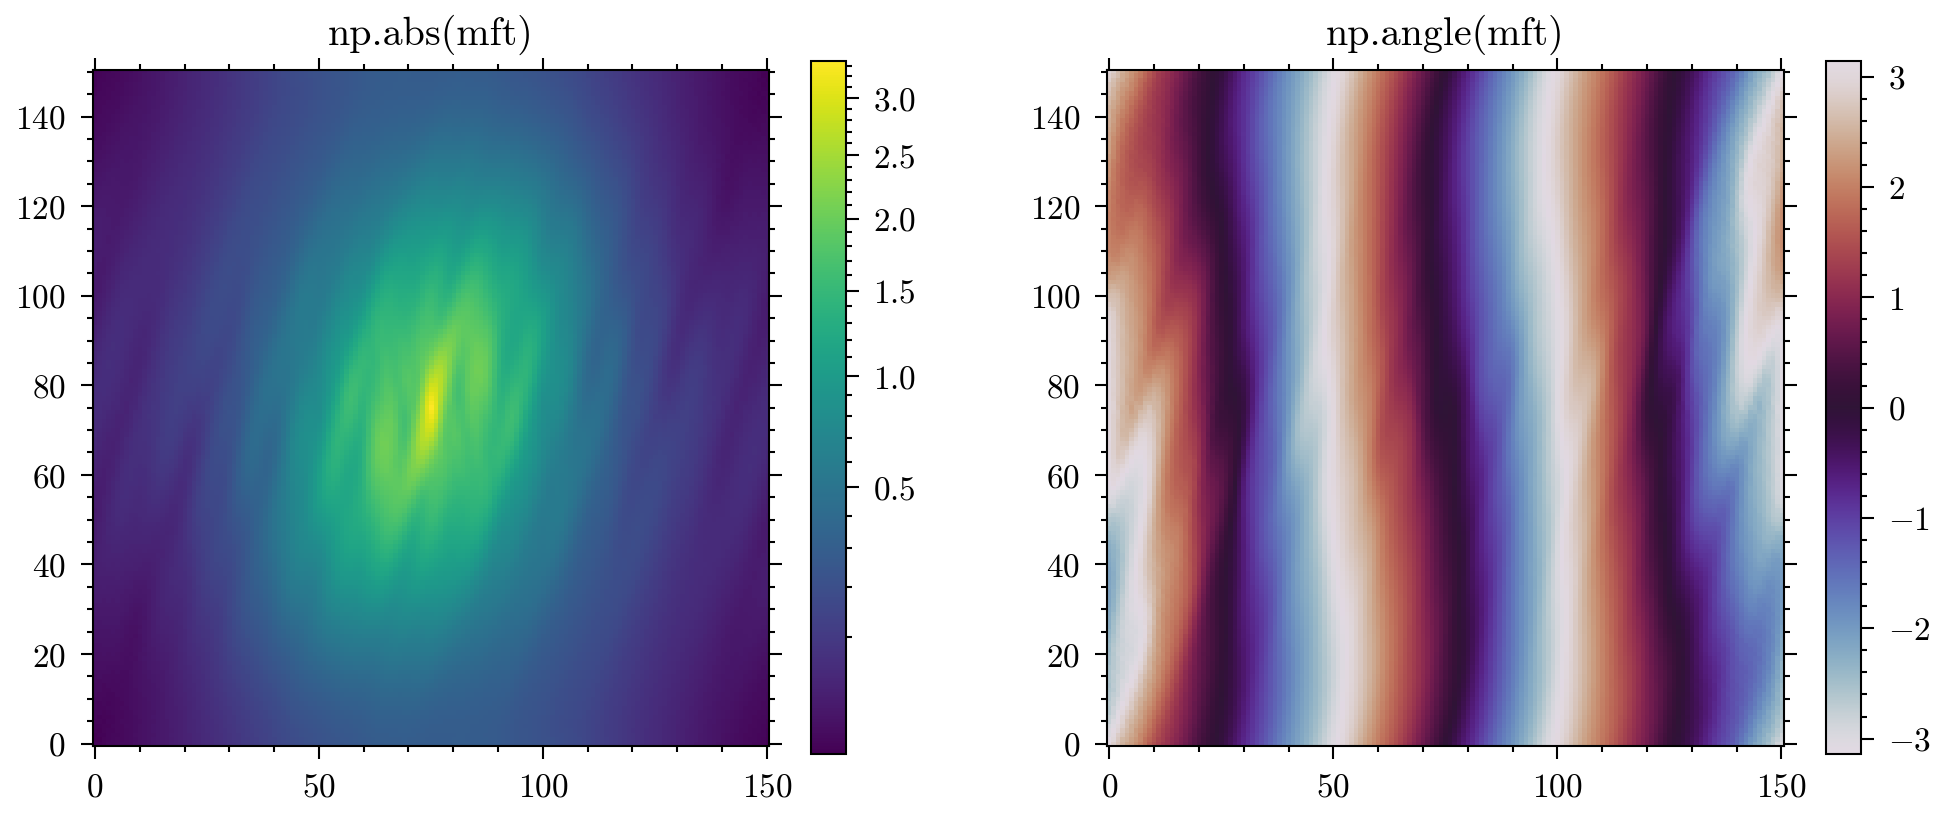

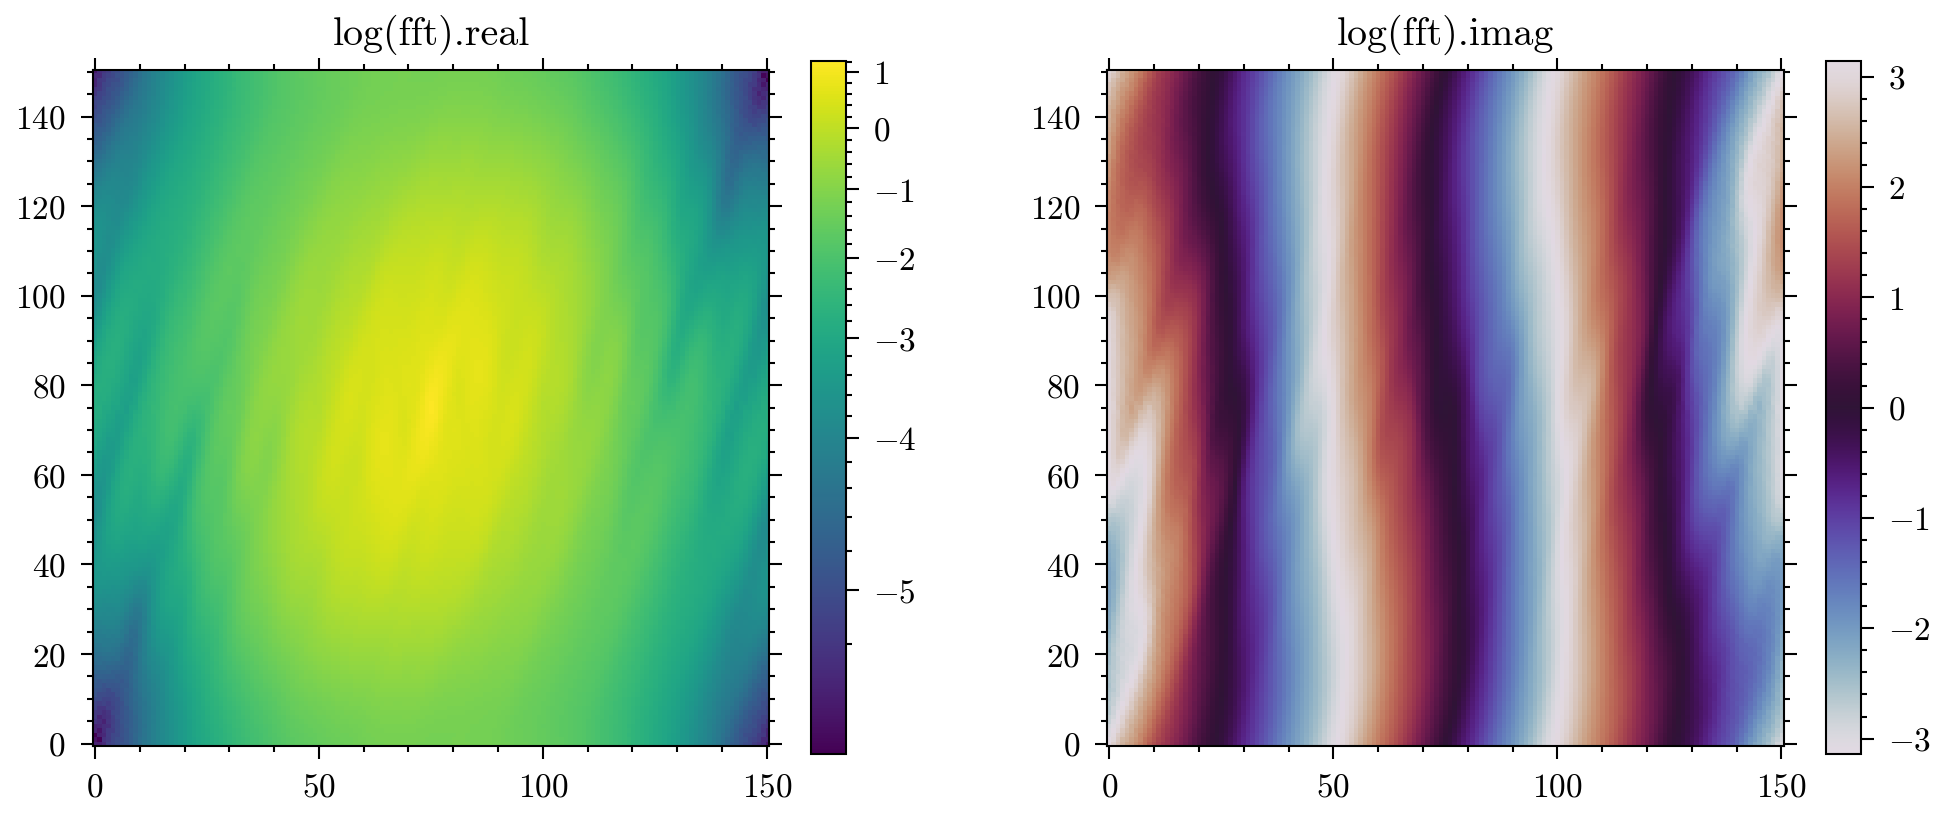

In [11]:
fft = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(interferogram)))

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.imshow(
    np.abs(fft),
    norm=mpl.colors.PowerNorm(0.5),
    cmap=viridis,
)
plt.title("np.abs(mft)")
plt.colorbar()
plt.subplot(122)
plt.imshow(
    np.angle(fft),
    cmap="twilight",
    origin="lower",
)
plt.colorbar()
plt.title("np.angle(mft)")
plt.show()

log_vis = np.log(fft)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.imshow(
    log_vis.real,
    norm=mpl.colors.PowerNorm(0.5),
    cmap=viridis,
)
plt.title("log(fft).real")
plt.colorbar()
plt.subplot(122)
plt.imshow(
    log_vis.imag,
    cmap="twilight",
    origin="lower",
)
plt.colorbar()
plt.title("log(fft).imag")
plt.show()

01260_F480M
File 01260_103_02_03_1
Star NGC1068
Filter F480M
nints 91
ngroups 4



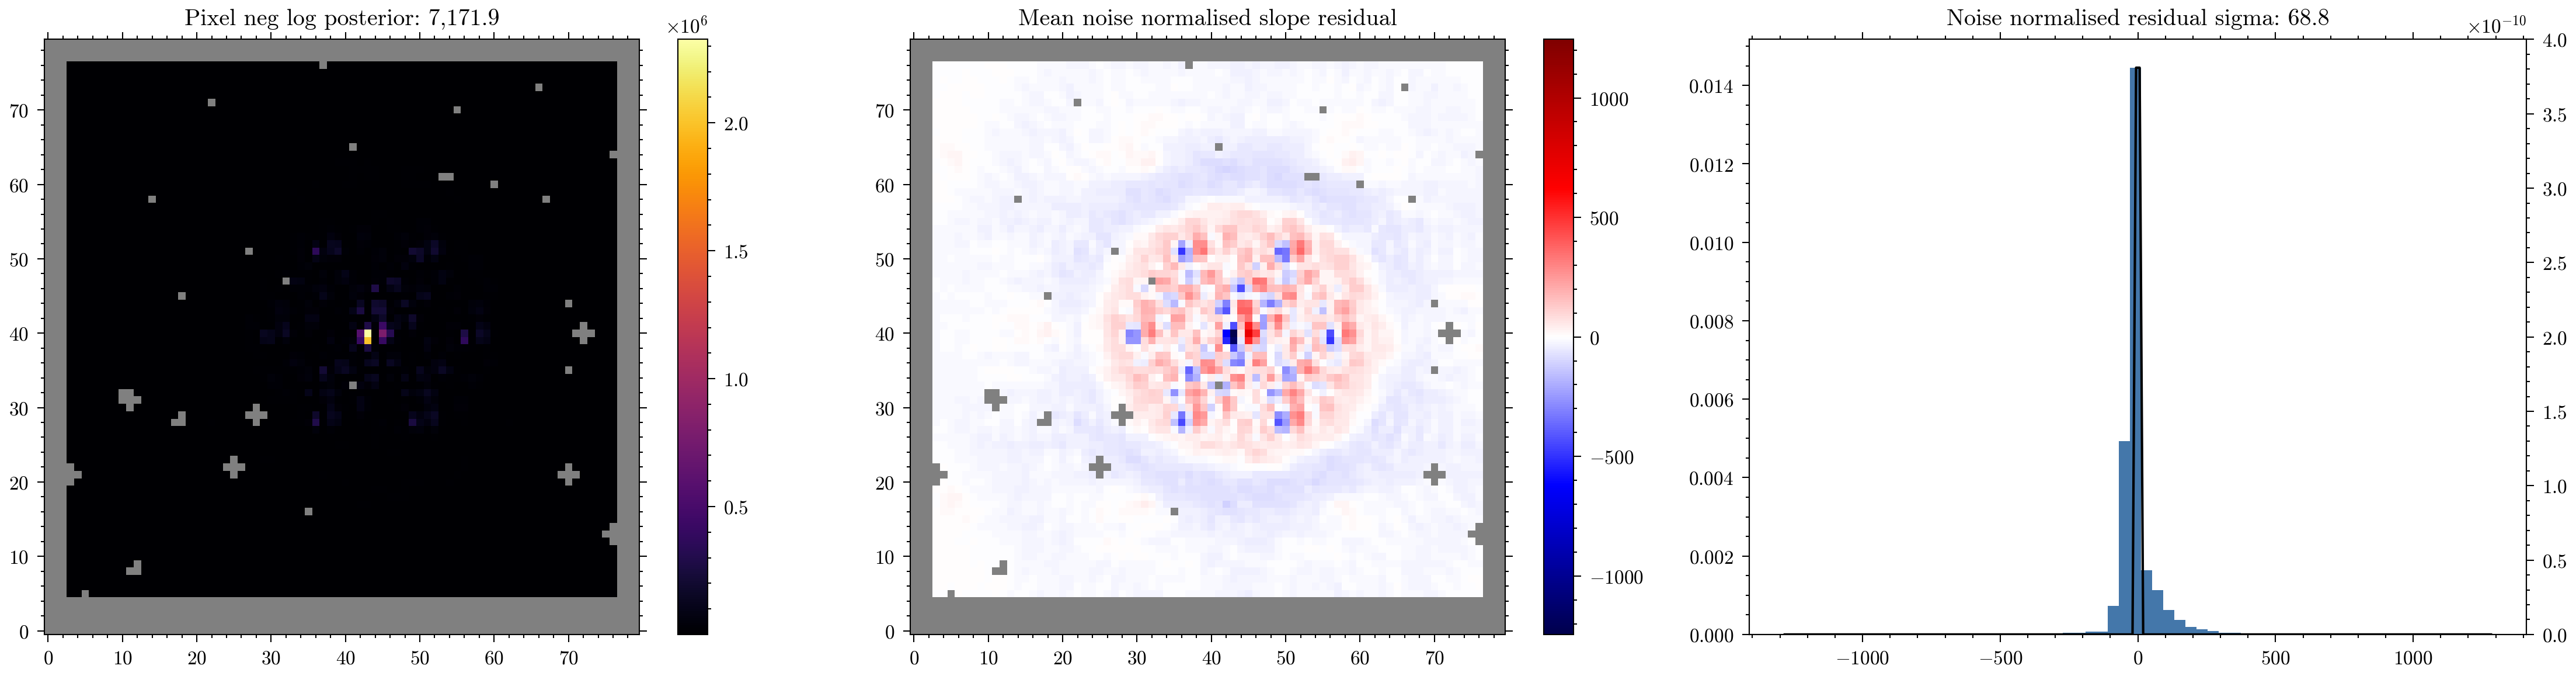

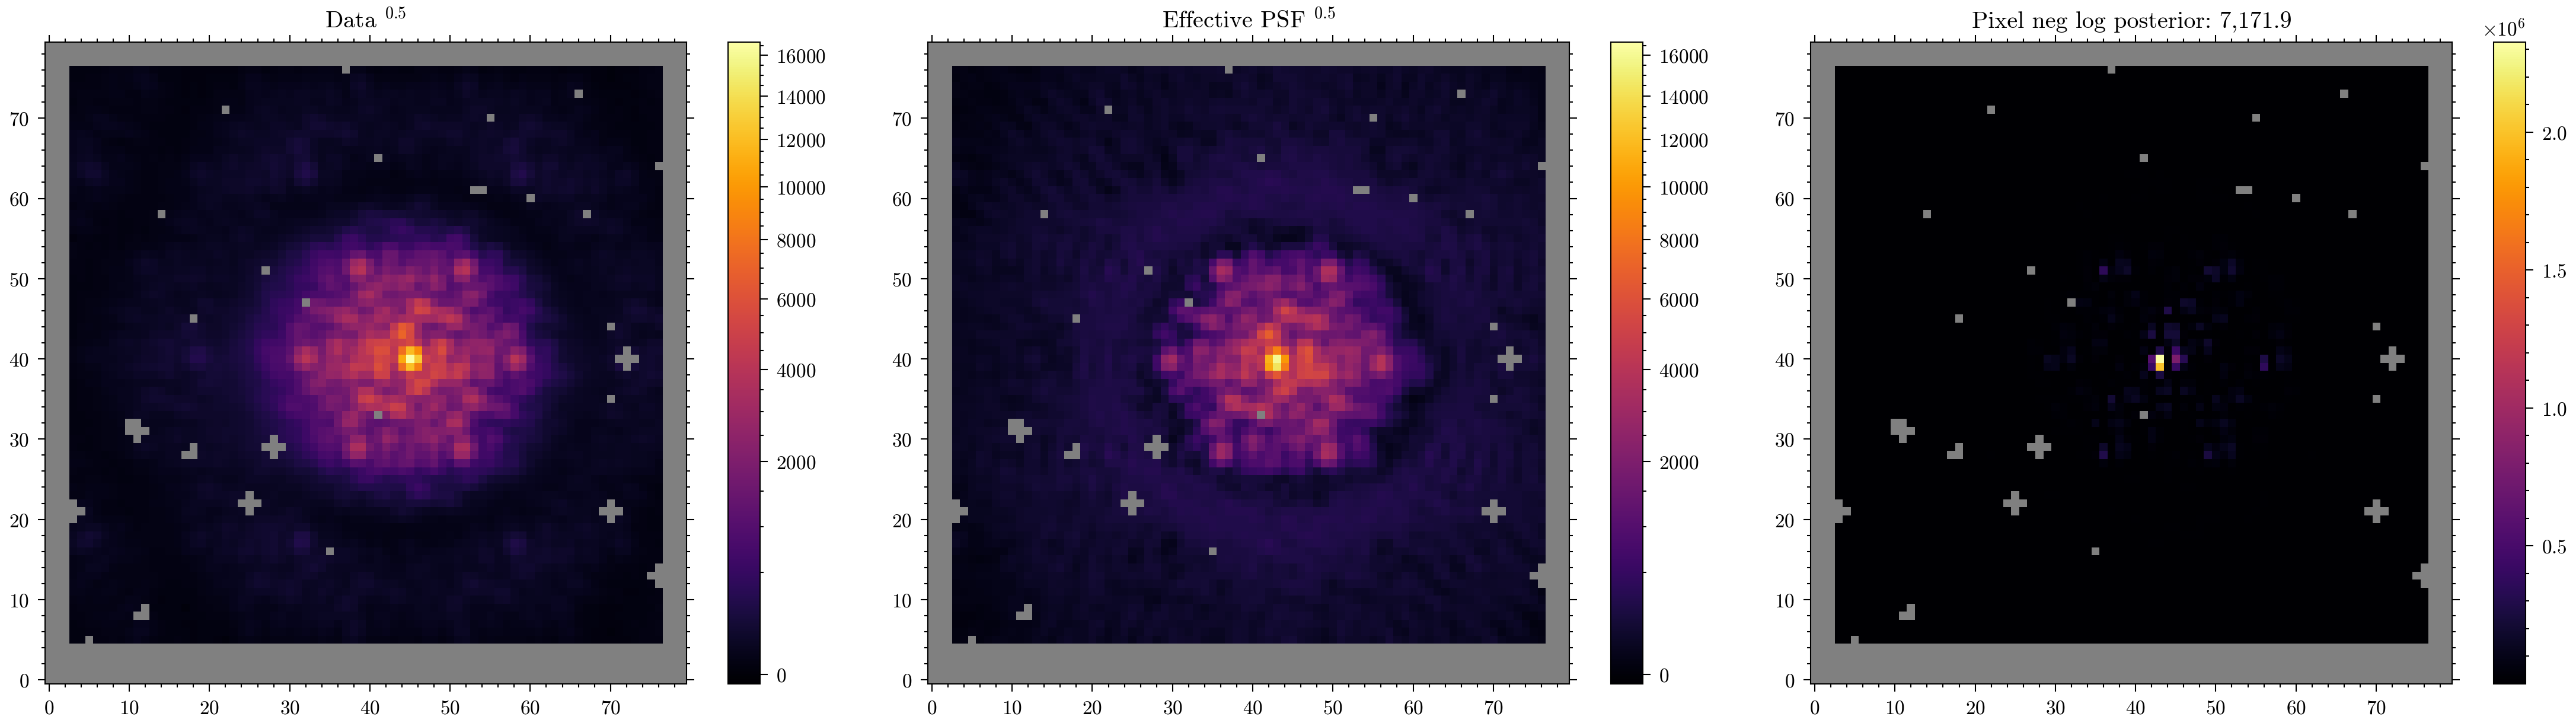

In [12]:
for exp in exposures:
    print(exp.get_key("aberrations"))
    exp.print_summary()
    r = False if exp.calibrator else True
    amigo.plotting.summarise_fit(model, exp, residuals=r)

In [13]:
# ngc = np.load("good_ngc.npy")[15:-15, 15:-15]

# plt.imshow(ngc, norm=mpl.colors.LogNorm(vmin=1e-5), cmap="inferno")
# plt.colorbar()
# plt.title("NGC1068 Image")
# plt.show()


# mft_fn = lambda array: dlu.MFT(
#     phasor=array,
#     wavelength=wavel,
#     pixel_scale_in=dlu.arcsec2rad(model.psf_pixel_scale) / 3,
#     npixels_out=otf_coords.shape[-1],
#     pixel_scale_out=np.diff(otf_coords[0, 0]).mean(),
#     inverse=False,
# )

# mft = mft_fn(ngc)
# base = mft_fn(np.zeros_like(ngc).at[ngc.shape[0] // 2, ngc.shape[1] // 2].set(1.0))

# mft /= base

# plt.figure(figsize=(8, 3))
# plt.subplot(121)
# plt.imshow(
#     np.abs(mft),
#     norm=mpl.colors.PowerNorm(0.5),
#     cmap=viridis,
# )
# plt.title("np.abs(mft)")
# plt.colorbar()
# plt.subplot(122)
# plt.imshow(
#     np.angle(mft),
#     cmap="twilight",
#     origin="lower",
# )
# plt.colorbar()
# plt.title("np.angle(mft)")
# plt.show()

# log_vis = np.log(mft)

# plt.figure(figsize=(8, 3))
# plt.subplot(121)
# plt.imshow(
#     log_vis.real,
#     norm=mpl.colors.PowerNorm(0.5),
#     cmap=viridis,
# )
# plt.title("log(mft).real")
# plt.colorbar()
# plt.subplot(122)
# plt.imshow(
#     log_vis.imag,
#     cmap="twilight",
#     origin="lower",
# )
# plt.colorbar()
# plt.title("log(mft).imag")
# plt.show()

# BACK ON TRACK

In [14]:
pos_keys = []
spc_keys = []
for exp in exposures:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def norm_fn(model_params, args):
    params = model_params.params

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args

In [15]:
n_epoch = 500
# n_epoch = 100

config = {
    "positions": sgd(1e0, 0, (30, 0.0)),
    "fluxes": sgd(5e-2, 5),
    # "aberrations": sgd(2e0, 8),
    "spectra": sgd(5e-1, 100),
    # "amplitudes": sgd(1e1, 20),
    # "phases": sgd(1e1, 20),
    # "amplitudes": sgd(5e-1, 20),
    # "phases": sgd(5e-1, 20),
    "amplitudes": sgd(2e0, 30),
    "phases": sgd(2e0, 30),
}


def grad_fn(model, grads, args):
    # Nuke the position gradients for the science exposures
    if "positions" in config.keys():
        grads = grads.multiply(pos_keys, 0.1)

    # Reduce spectra gradients for the science exposures
    if "spectra" in config.keys():
        # grads = grads.multiply(spc_keys, 0.0)
        grads = grads.multiply(spc_keys, 0.3)
    return grads, args


trainer = amigo.fitting.Trainer(
    grad_fn=grad_fn,
    norm_fn=norm_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    model,
    exposures,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=list(config.keys()),
)

print("Number of exposures: ", len(exposures))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exposures,
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=15),
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=len(exposures) // 3),
    # batches=exposures[-1:],
)

Number of exposures:  1


  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 7,168.44
Estimated run time: 0:15:27
Full Time: 0:15:47
Final Loss: 97.21


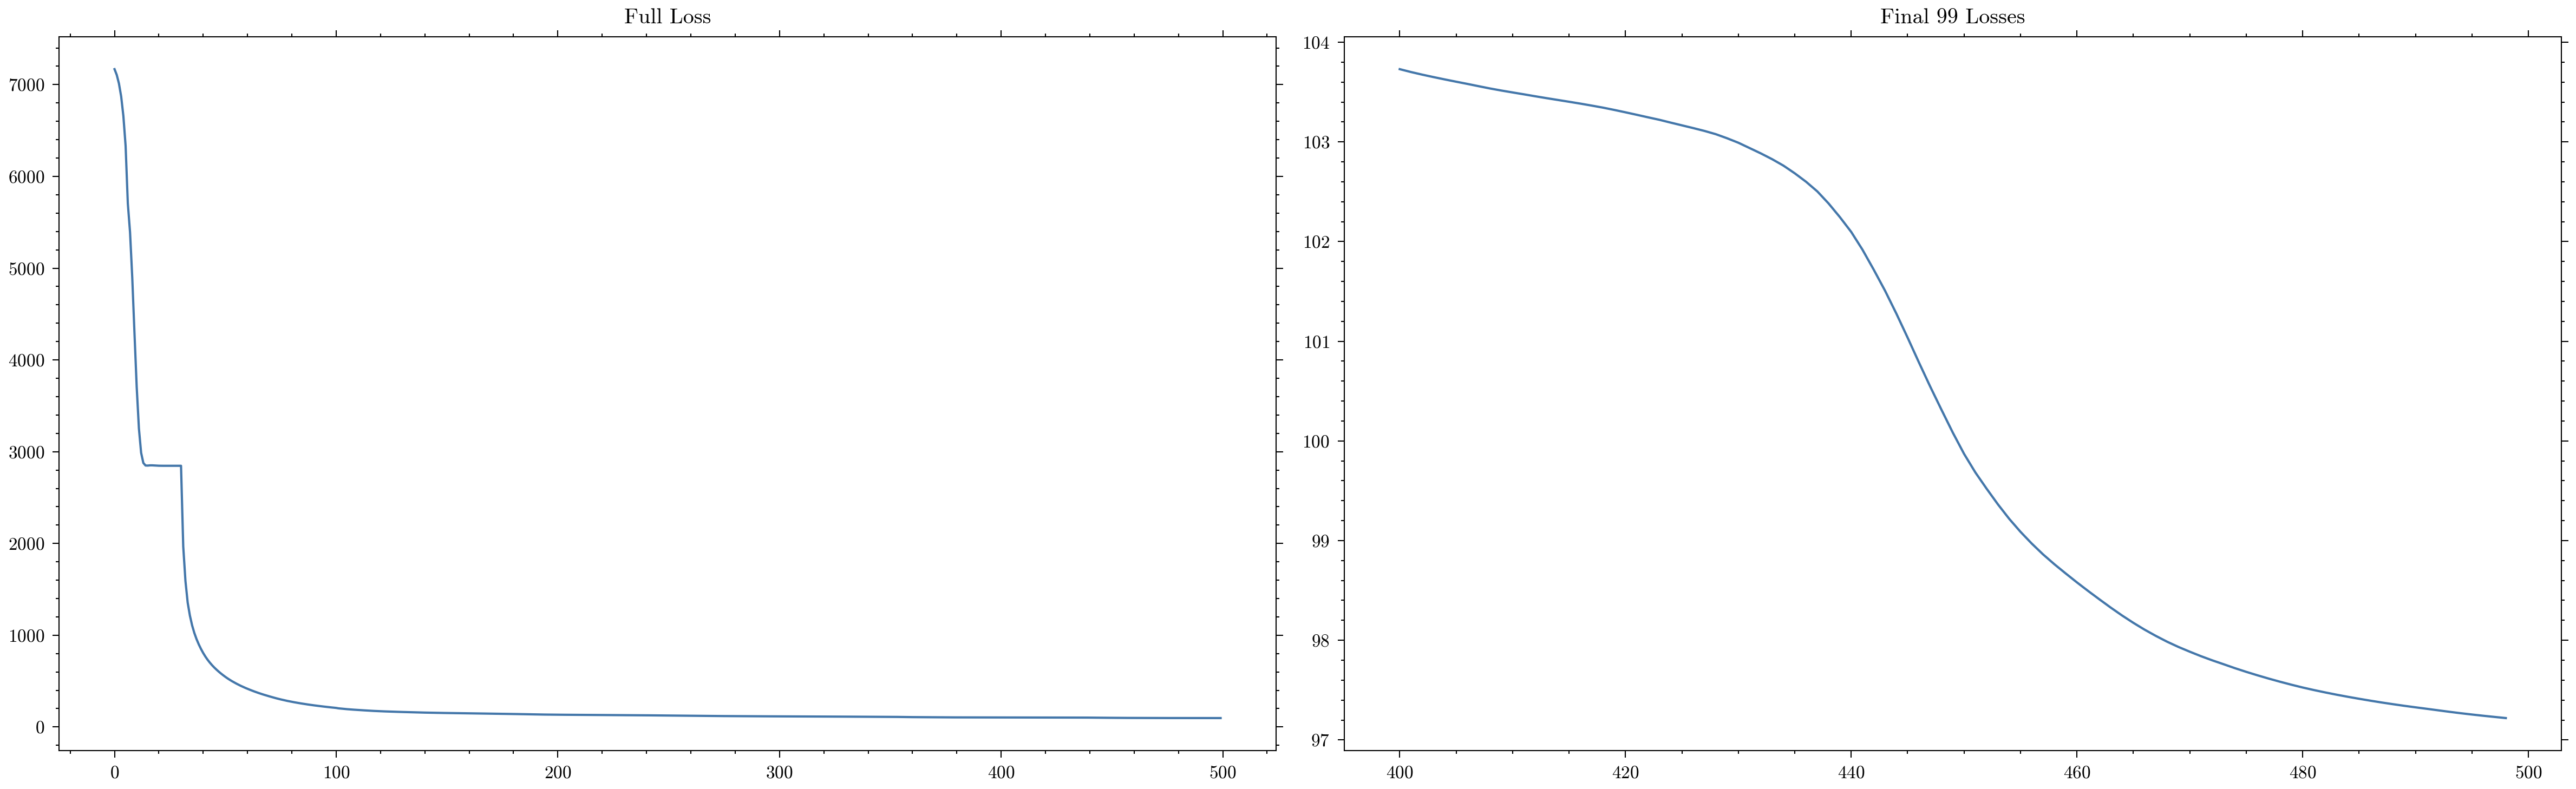

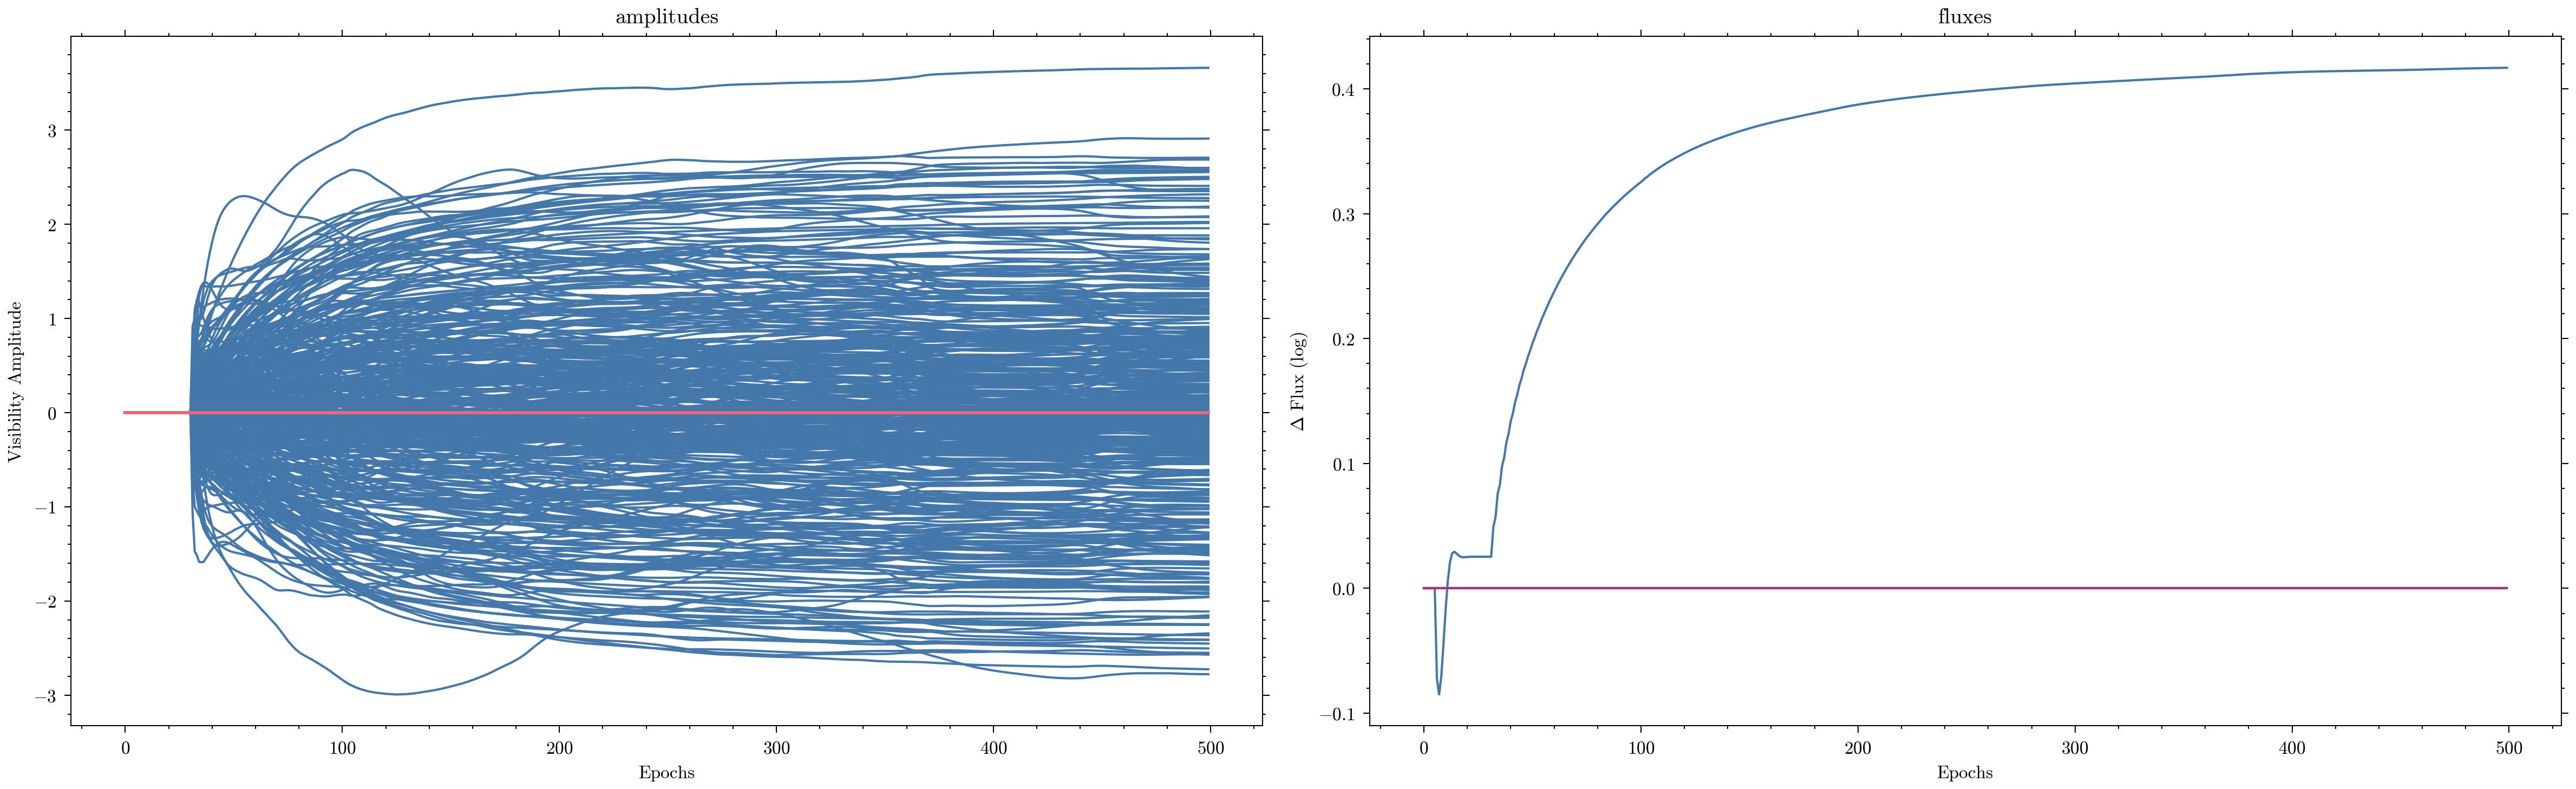

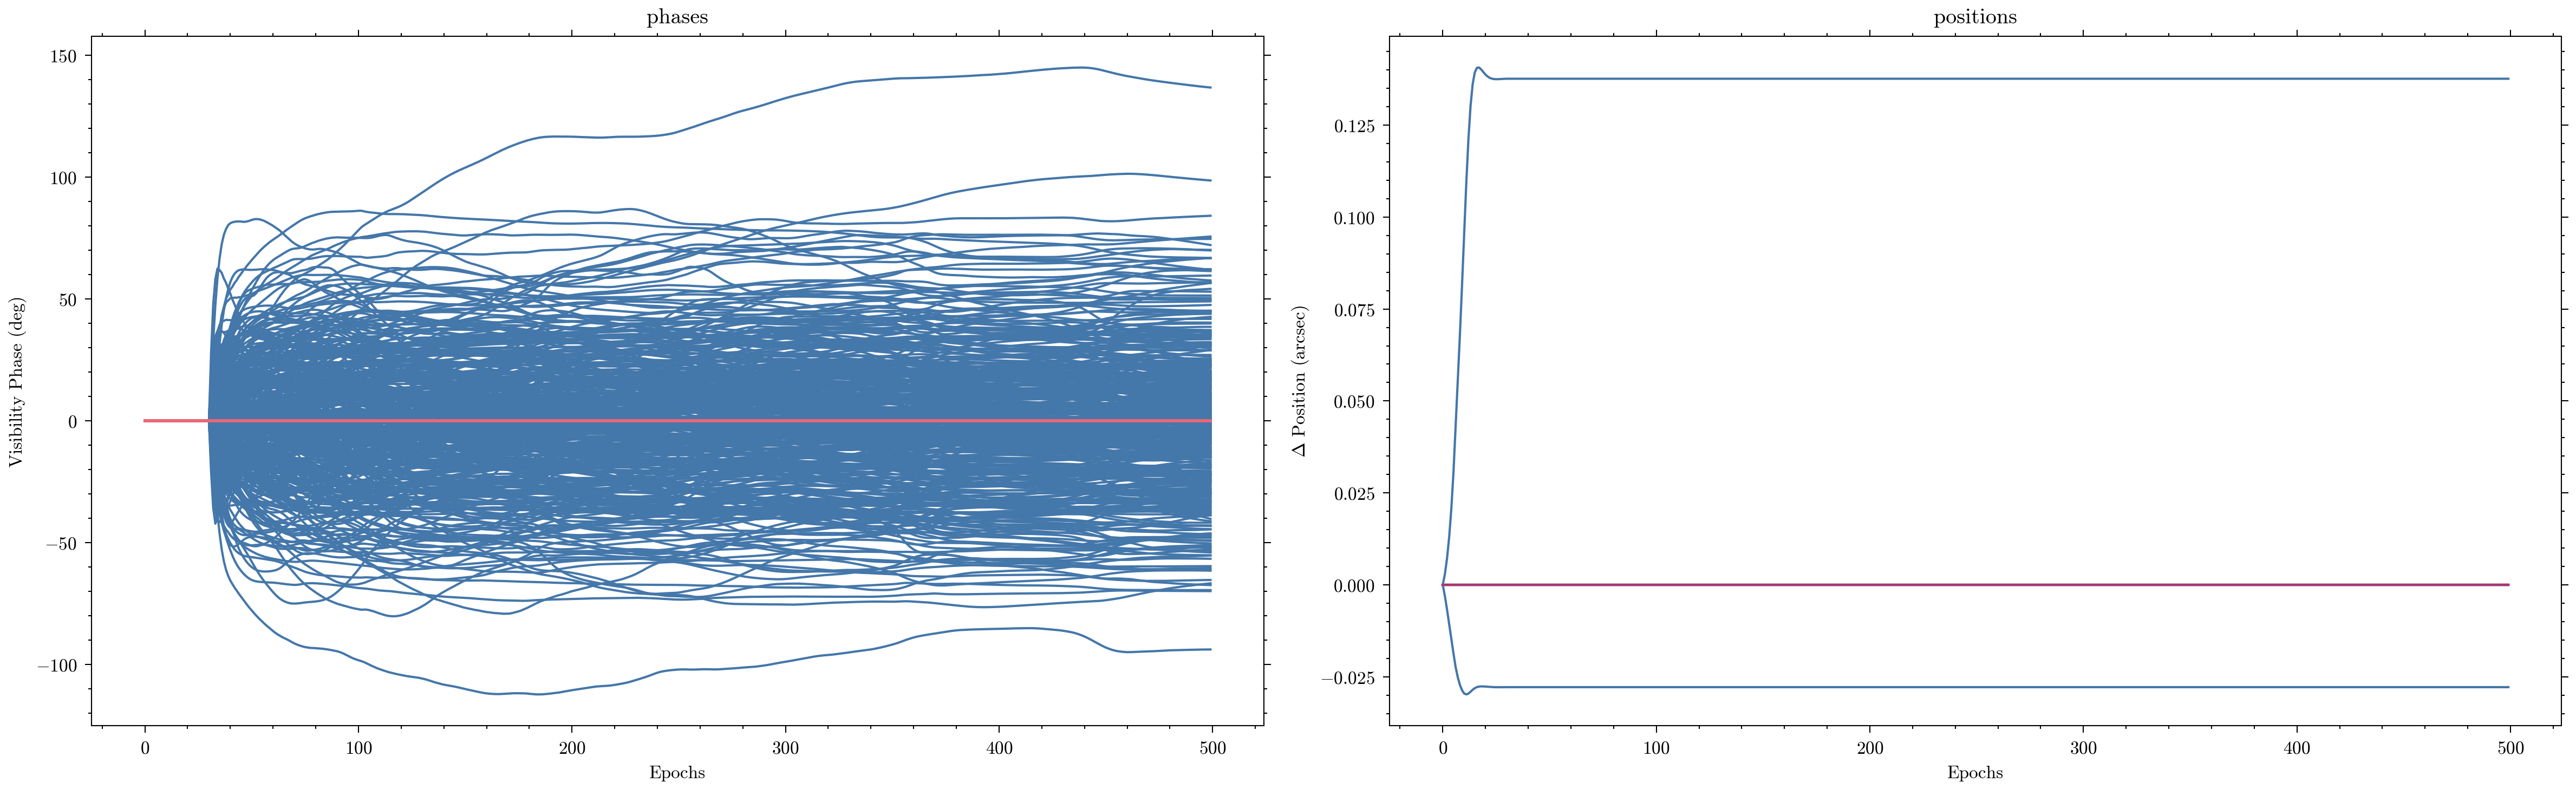

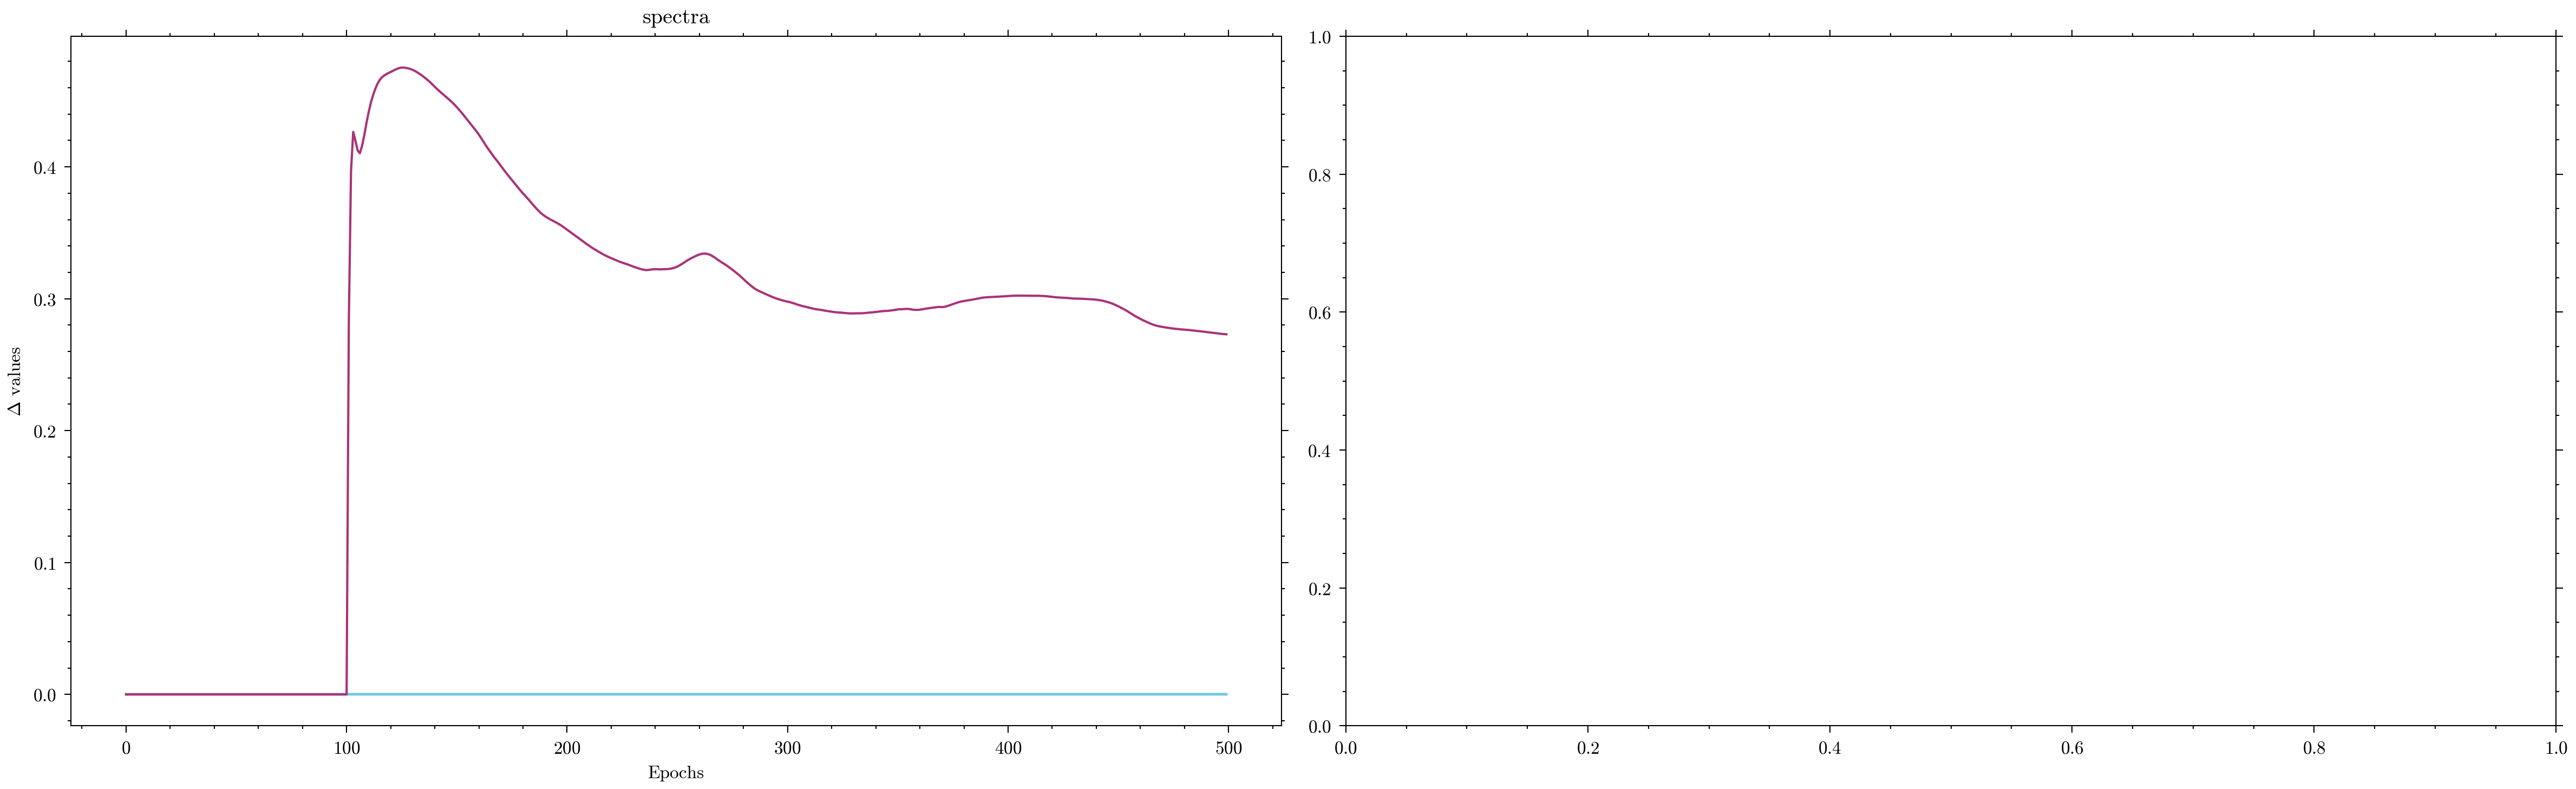

NGC1068


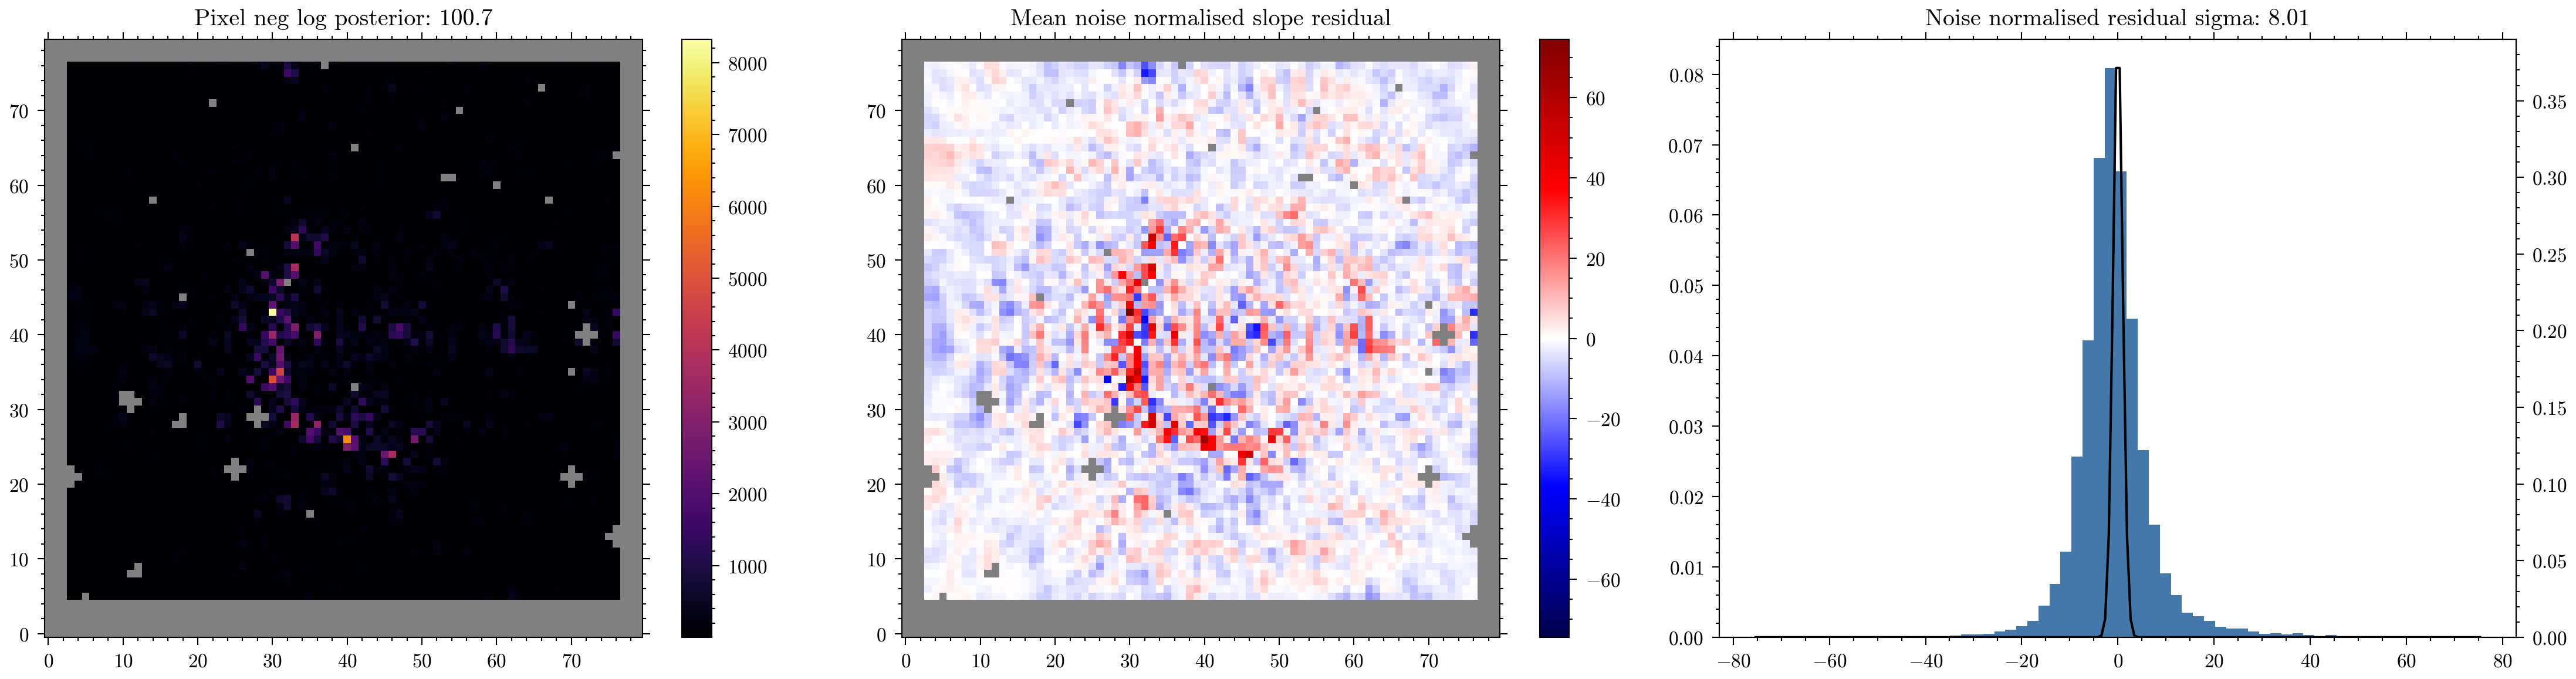

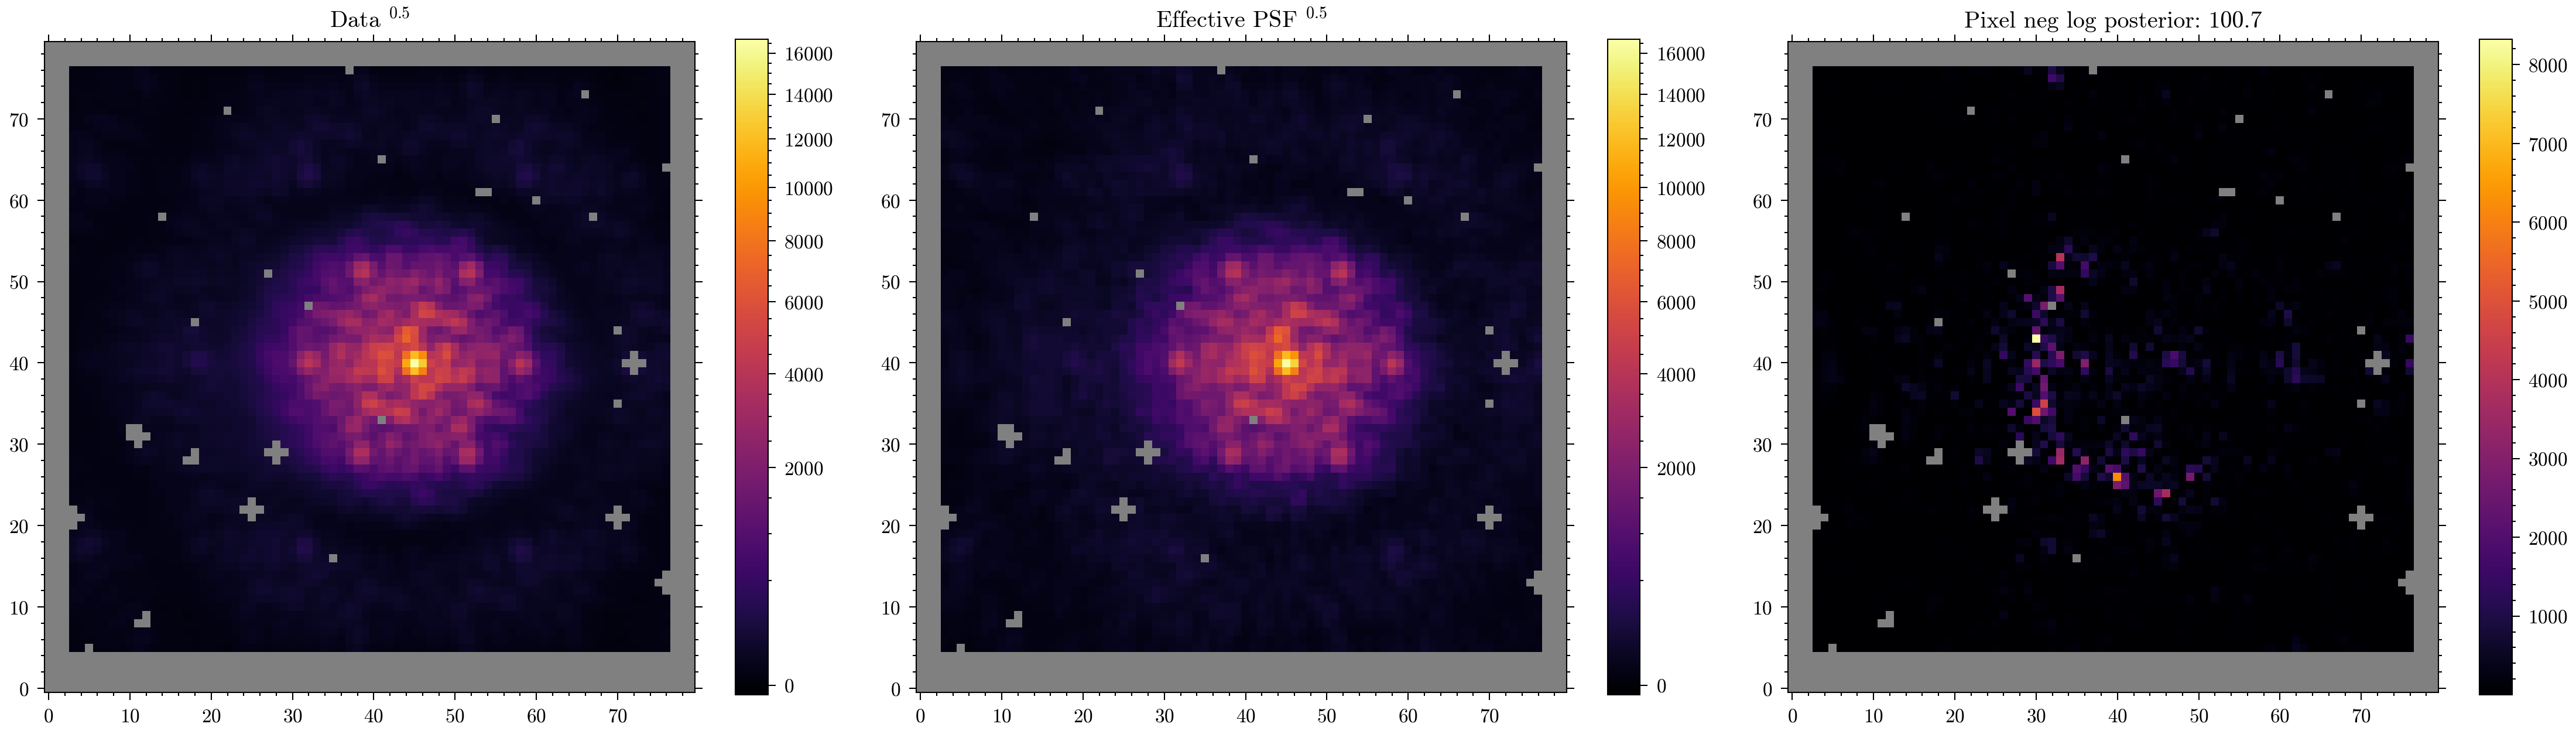

In [16]:
losses = np.array([v for v in result.losses.values()]).mean(0)

amigo.plotting.plot_losses(losses, start=int(0.8 * n_epoch))
amigo.plotting.plot(result.history)

# for exp in exposures:
for exp in exposures:
    print(exp.star)
    r = False if exp.calibrator else True
    amigo.plotting.summarise_fit(result.model, exp, r)

In [17]:
import zodiax as zdx

# zdx.experimental.serialise(output_path + "letstrythis.zdx", result.model.params)
# saved_params = zdx.experimental.deserialise(output_path + "letstrythis.zdx")
# result_model = model.set("params", saved_params)

result_model = result.model

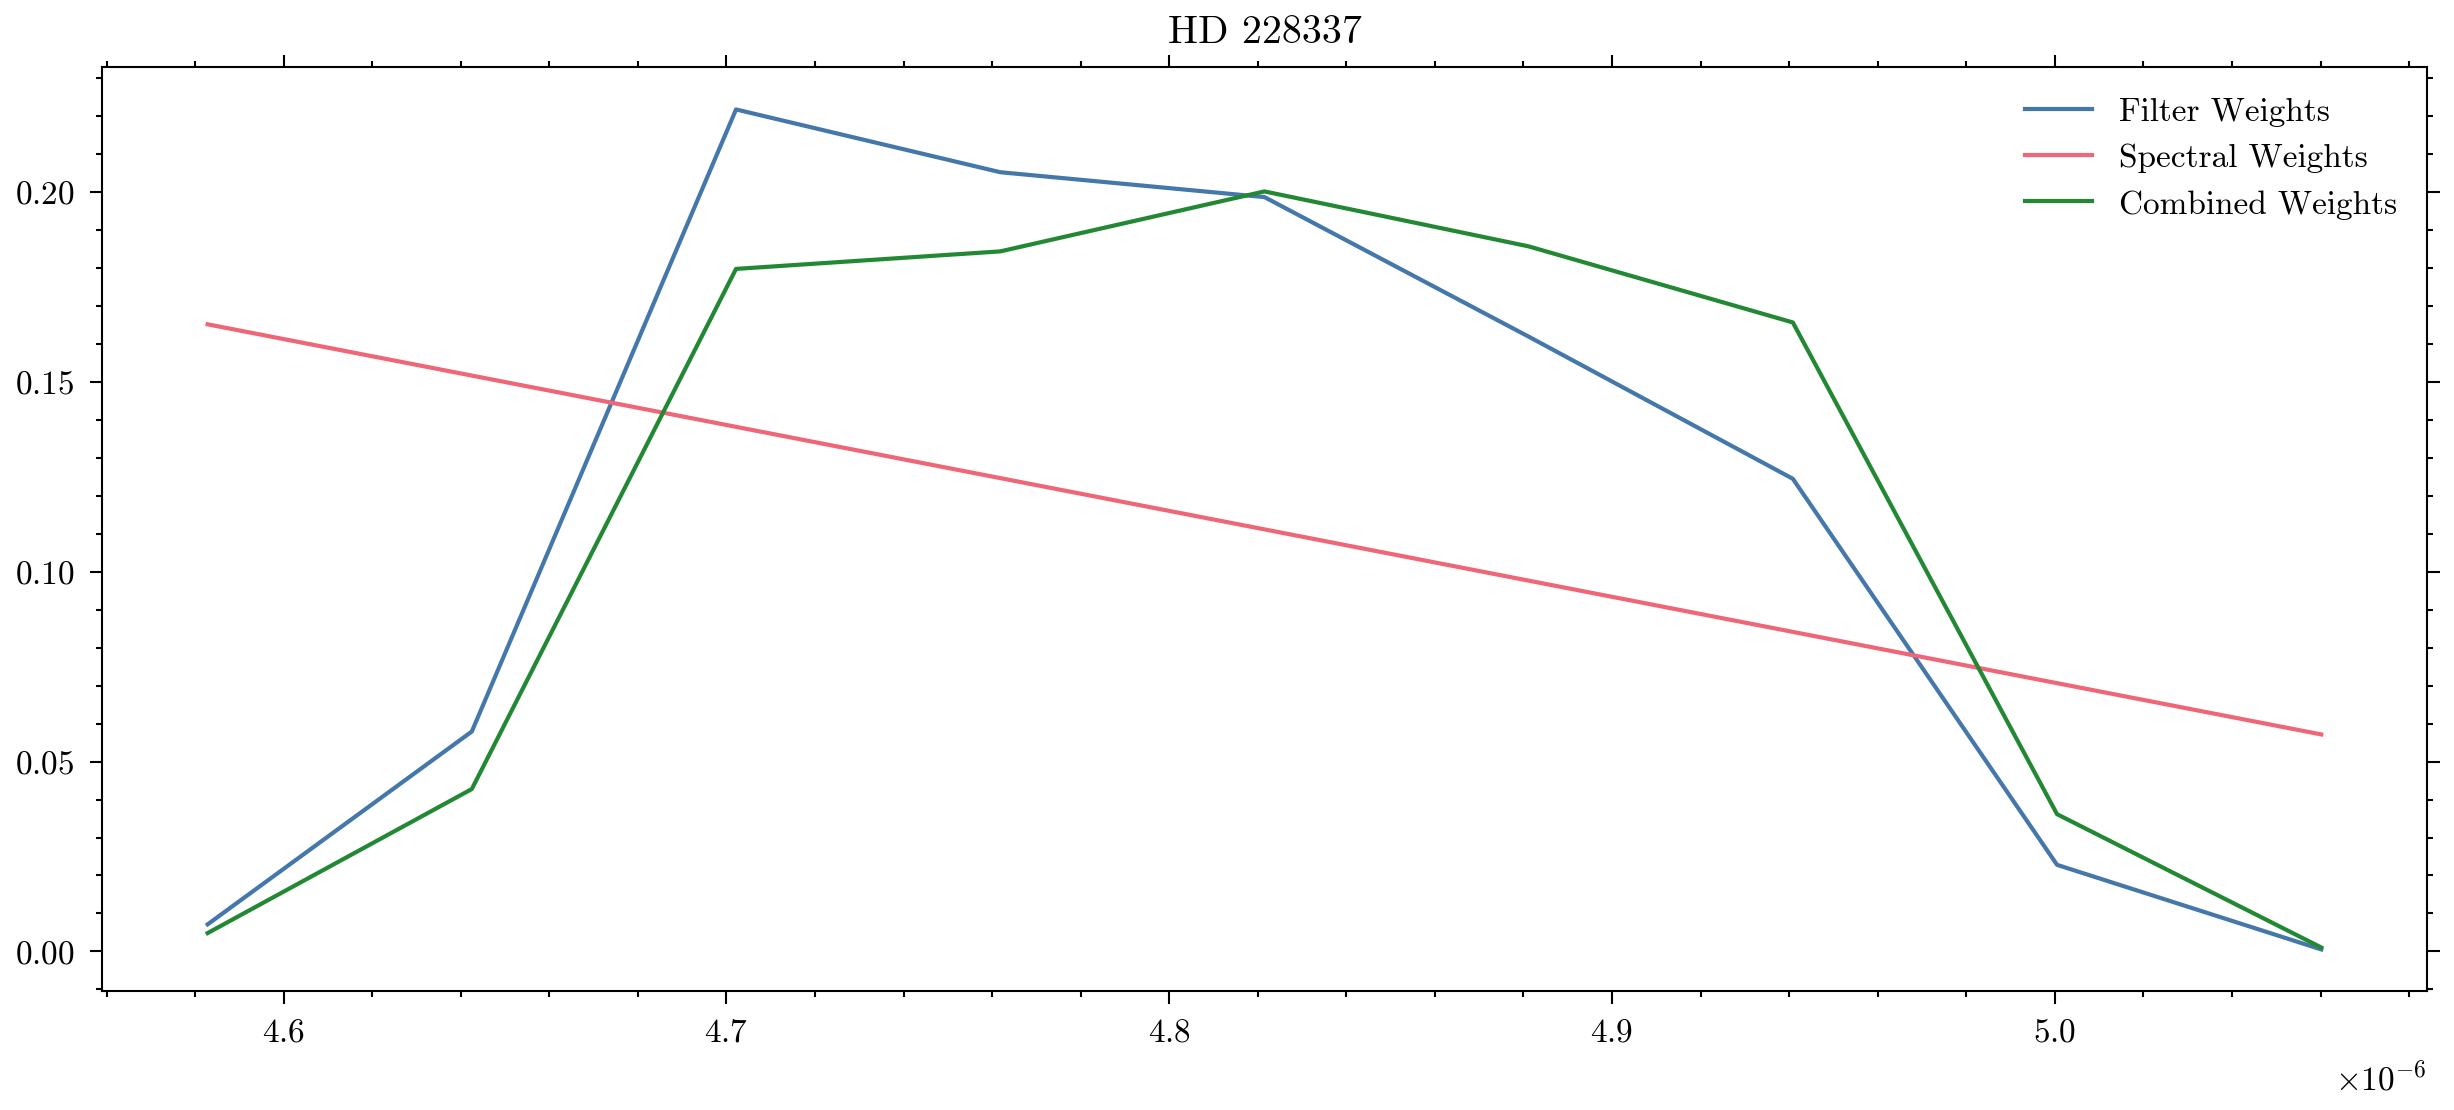

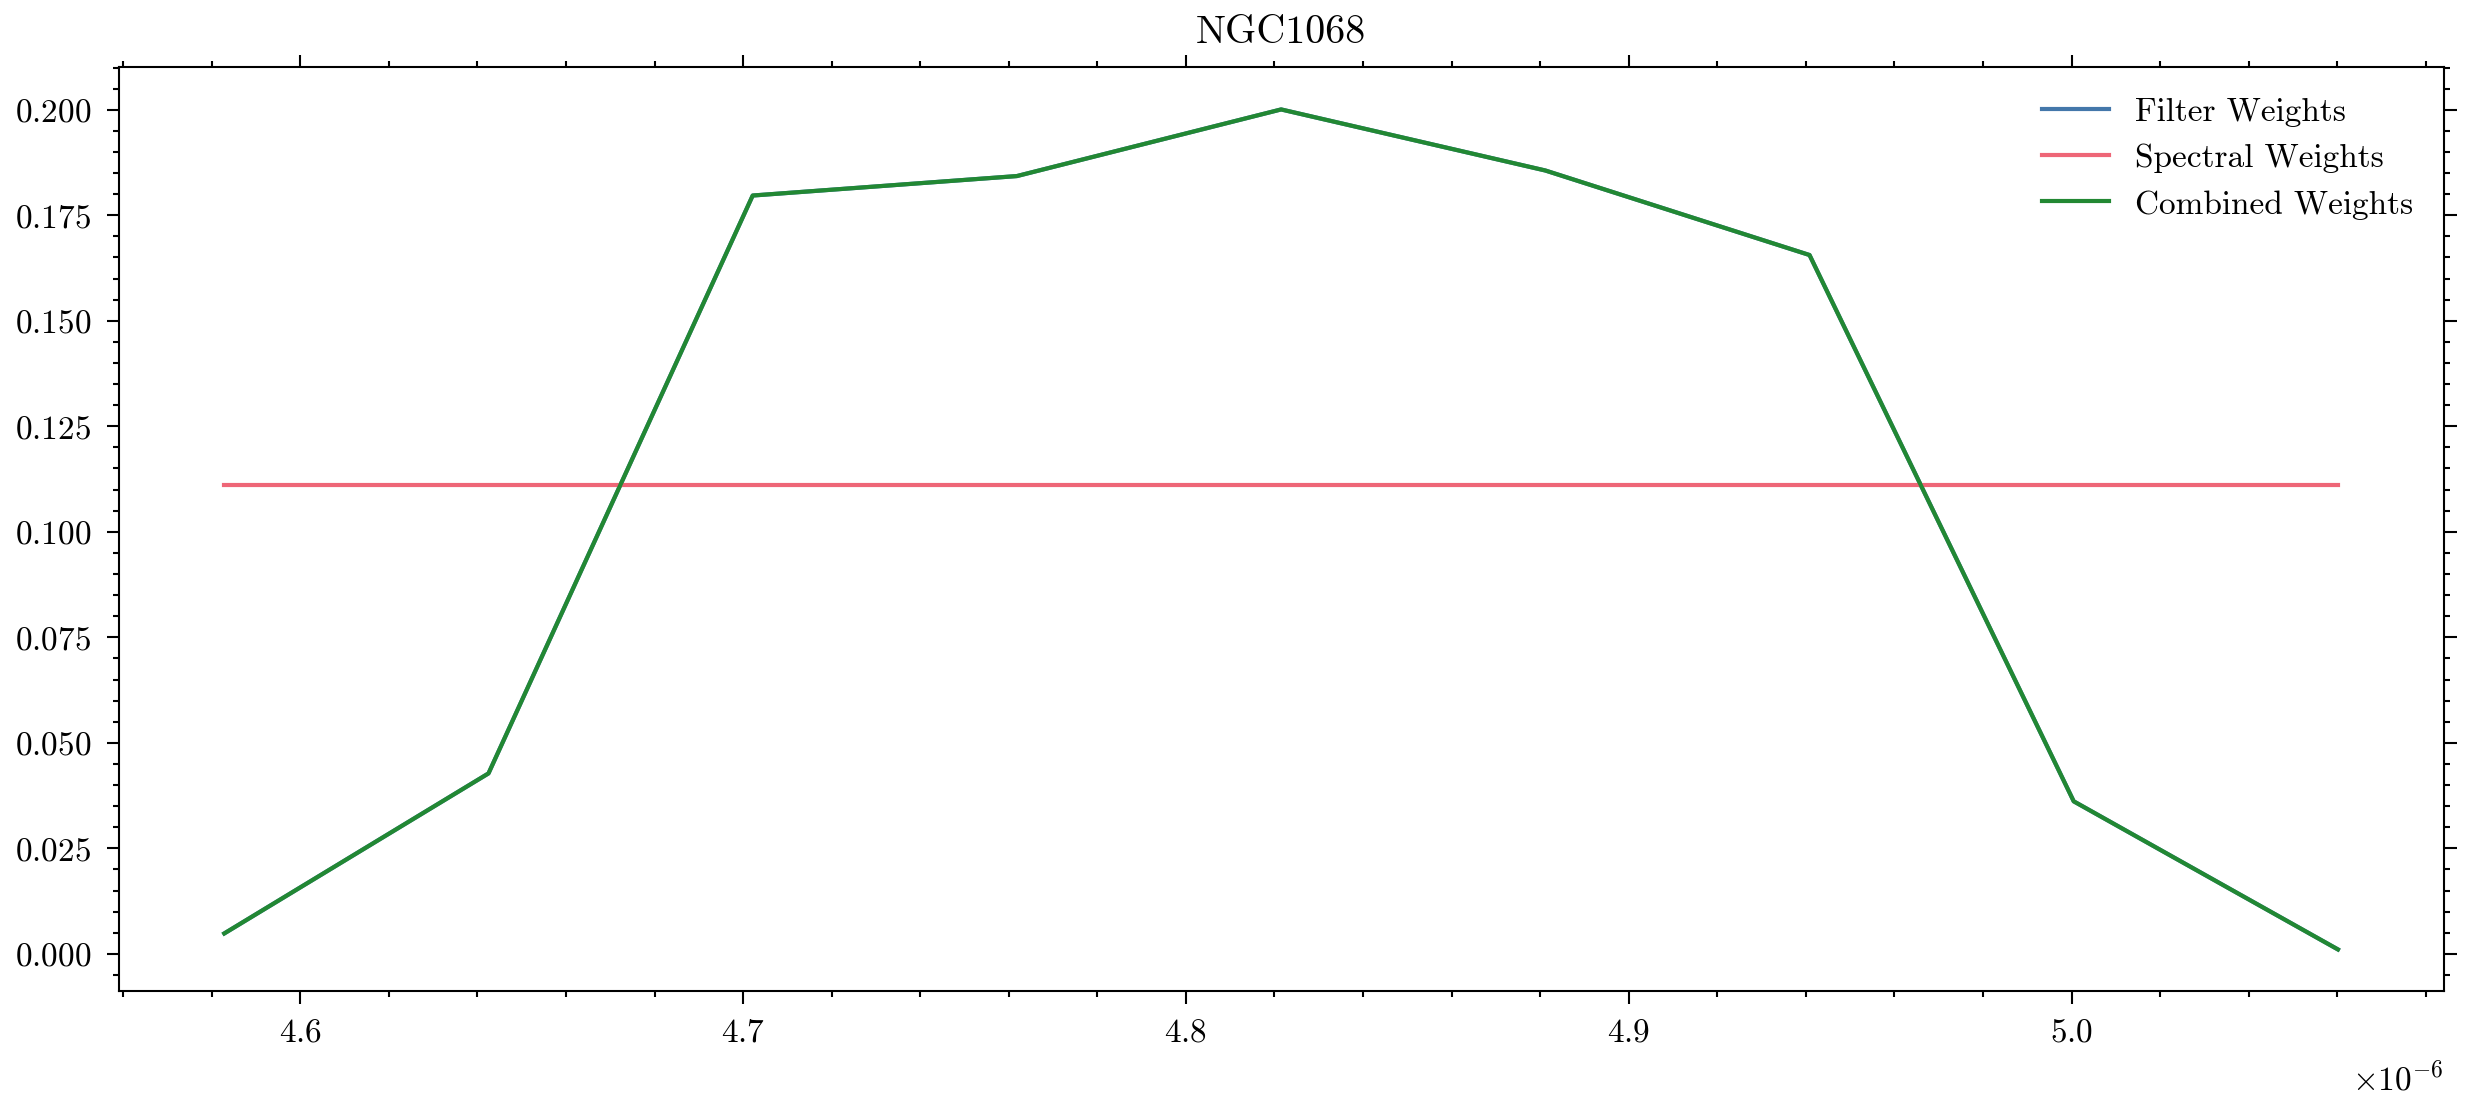

In [18]:
stars = list(set([exp.star for exp in exposures]))

for targ_star in stars:
    plt.figure(figsize=(10, 4))
    plt.title(f"{targ_star}")
    for key, spec in result_model.spectra.items():
        star, filt = key.split("_")

        if star != targ_star:
            continue

        wavels, filt_weights = model.filters[filt]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + spec * xs
        weights = filt_weights * spectra_slopes  # * wavels

        #
        filt_weights = filt_weights / filt_weights.sum()
        spectra_slopes = spectra_slopes / spectra_slopes.sum()
        weights = weights / weights.sum()

        plt.plot(wavels, weights, label="Filter Weights")
        plt.plot(wavels, spectra_slopes, label="Spectral Weights")
        plt.plot(wavels, filt_weights, label="Combined Weights")

    plt.legend()
    plt.show()

In [19]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams
from tqdm.notebook import tqdm


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = [
    "amplitudes",
    "phases",
    "fluxes",
    # "spectra",
]
final_model = result_model
# final_model = result.model

args_out = {}
sols_out = {}
for i, exp in enumerate(tqdm(exposures)):

    if exp.key in sols_out.keys():
        print(f"Skipping {exp.key} as it is already computed.")
        continue

    if exp.calibrator:
        print(f"Skipping {exp.key} as it is a calibrator.")
        continue

    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-8, atol=1e-8)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print(f"Final loss: {i}", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

  0%|          | 0/2 [00:00<?, ?it/s]

Skipping 01260_104_02_03_1 as it is a calibrator.
Initial loss: 178.8155746260958
Final loss: 1 86.6003026565824
2048 1519
The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.



In [20]:
# np.save("files/sols_out_O444.npy", sols_out, allow_pickle=True)
# np.save("files/args_out_O444.npy", args_out, allow_pickle=True)

In [21]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

#     # Spectra is joint-fit so we take the mean
#     exp = args[1]
#     spec = model_params.params[exp.map_param("spectra")]
#     spec_key = exp.get_key("spectra")
#     if spec_key not in spectra:
#         spectra[spec_key] = [spec]
#     else:
#         spectra[spec_key].append(spec)

# spectra = jtu.map(
#     lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
# )
# final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in config.items():
    # for key, values in result.state.items():
    final_state[key] = final_model.get(key)

F480M Calibrator HD 228337 6


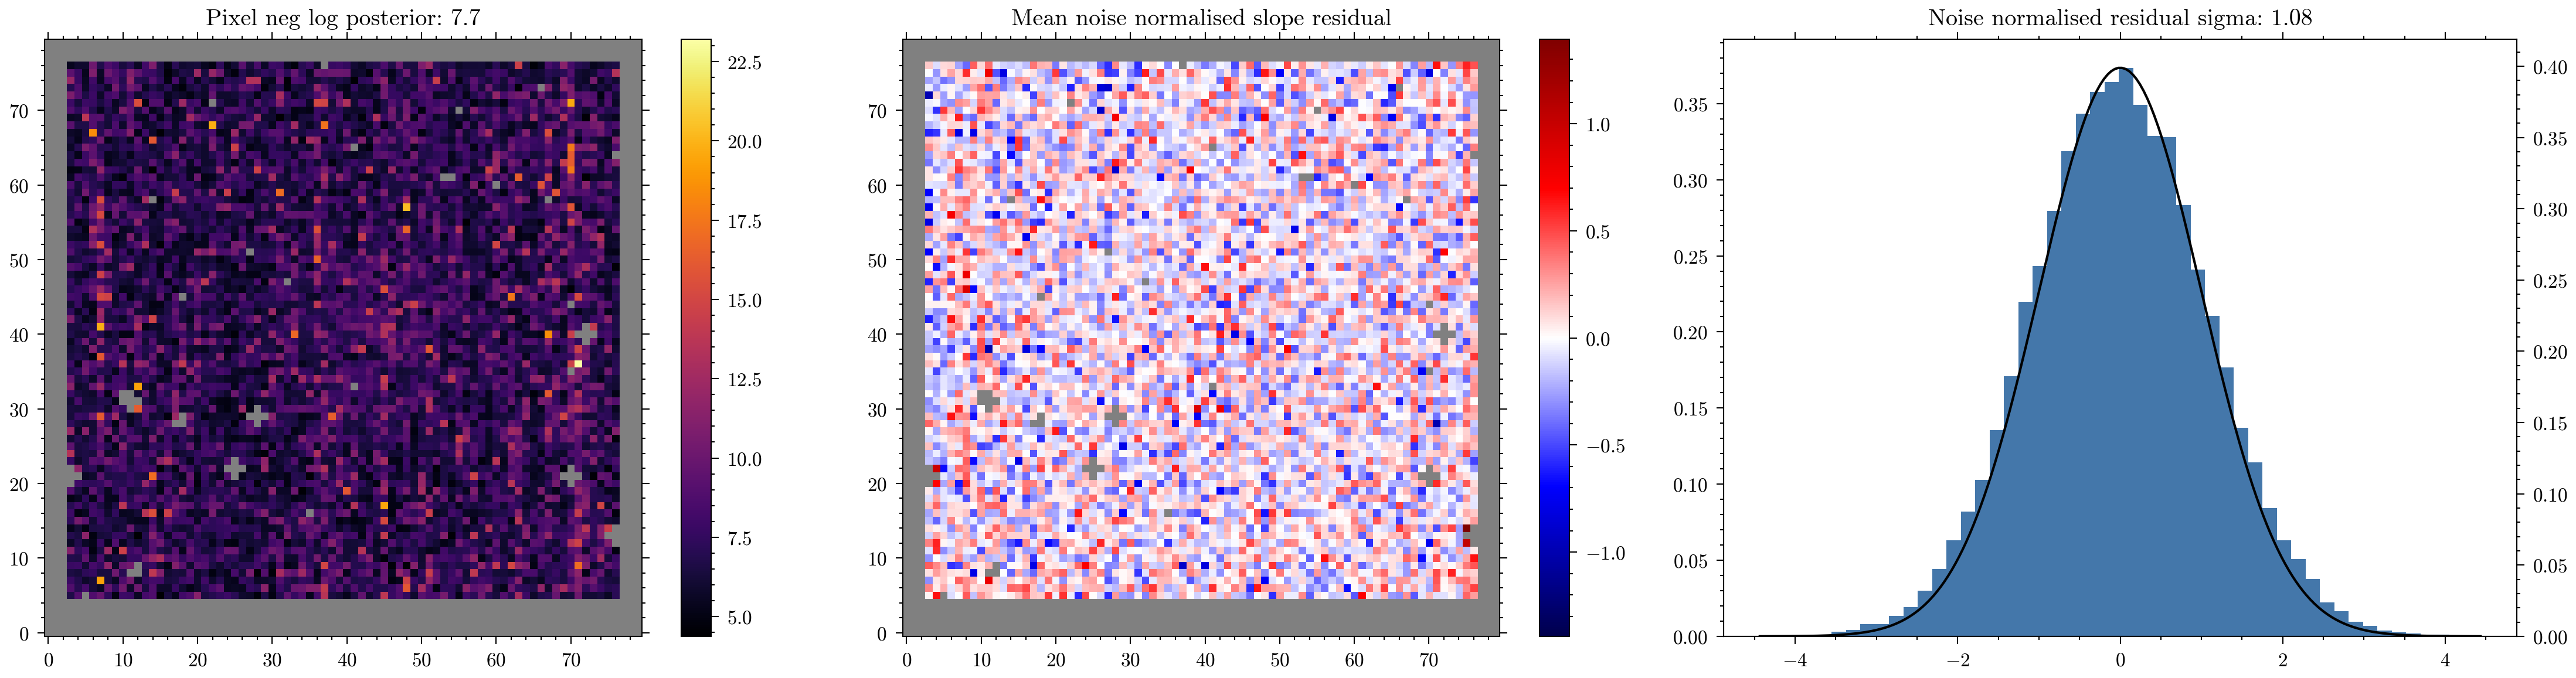

F480M Science NGC1068 4


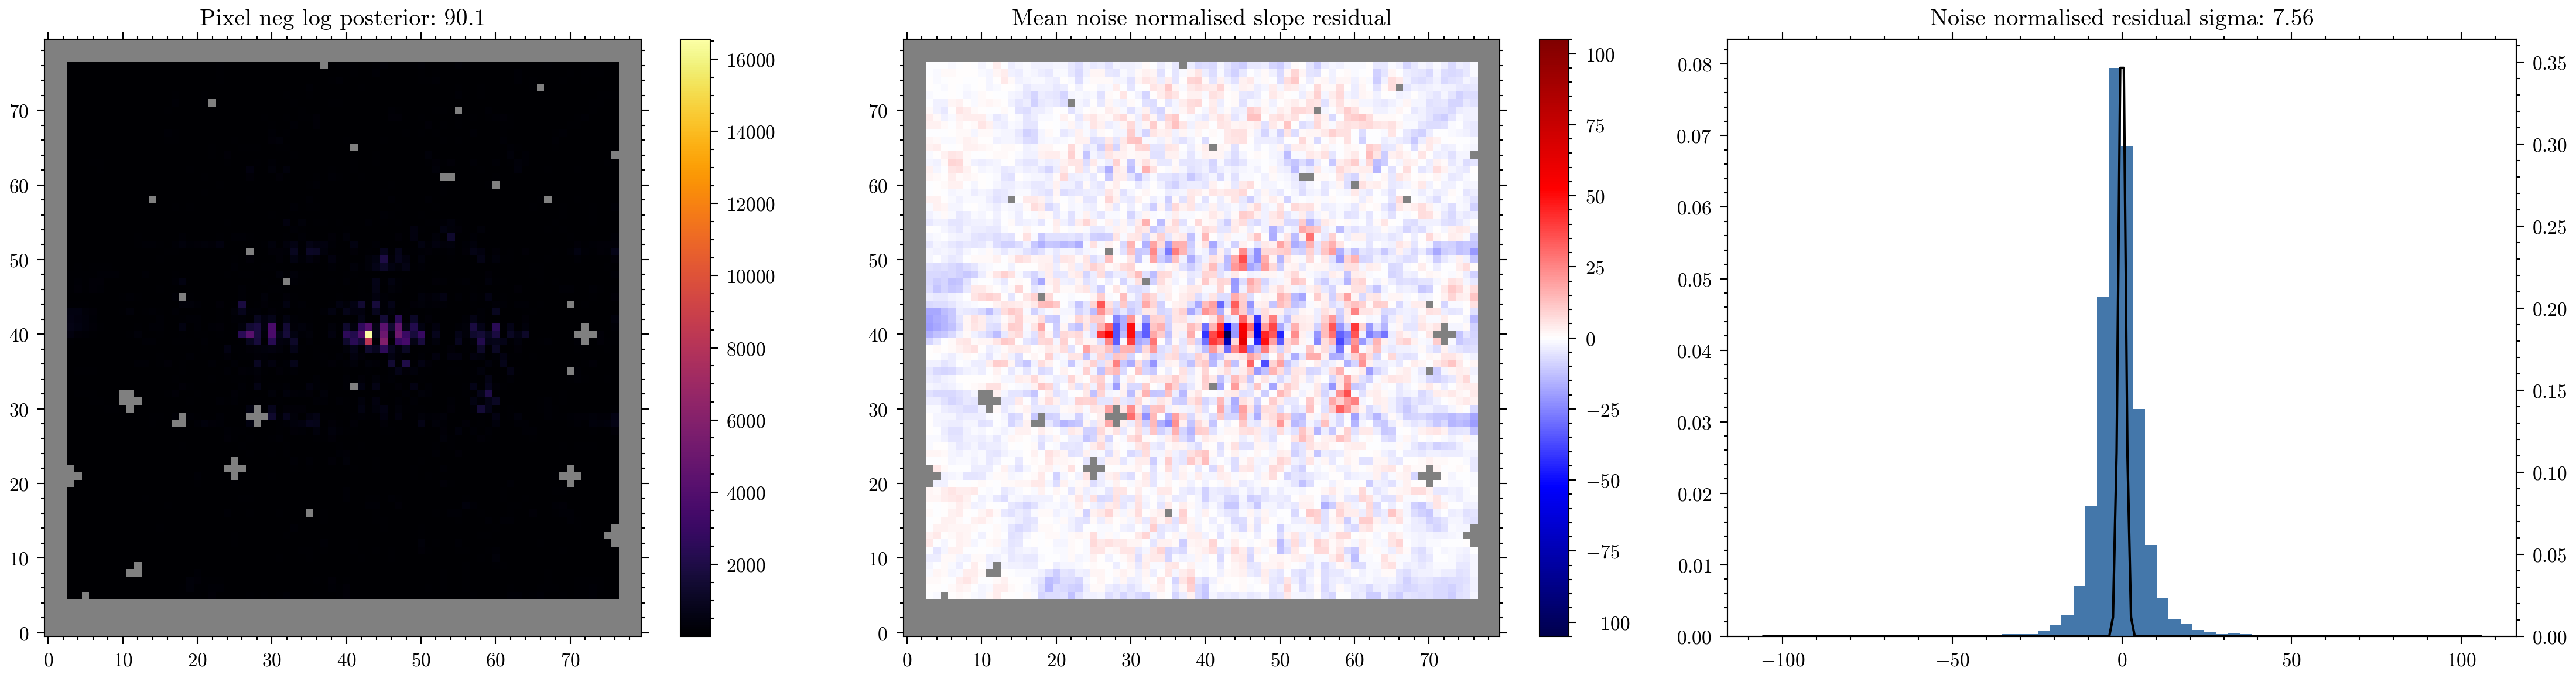

In [22]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exposures:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

In [21]:
import jax.tree as jtu
from tqdm.notebook import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    loglike_fn = lambda model: -np.nansum(exp.loglike(model))
    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(final_model, params, loglike_fn, reduce_ram=True, batch_size=10)
    fmats[exp.get_key("phases")] = fmat

  0%|          | 0/30 [00:00<?, ?it/s]

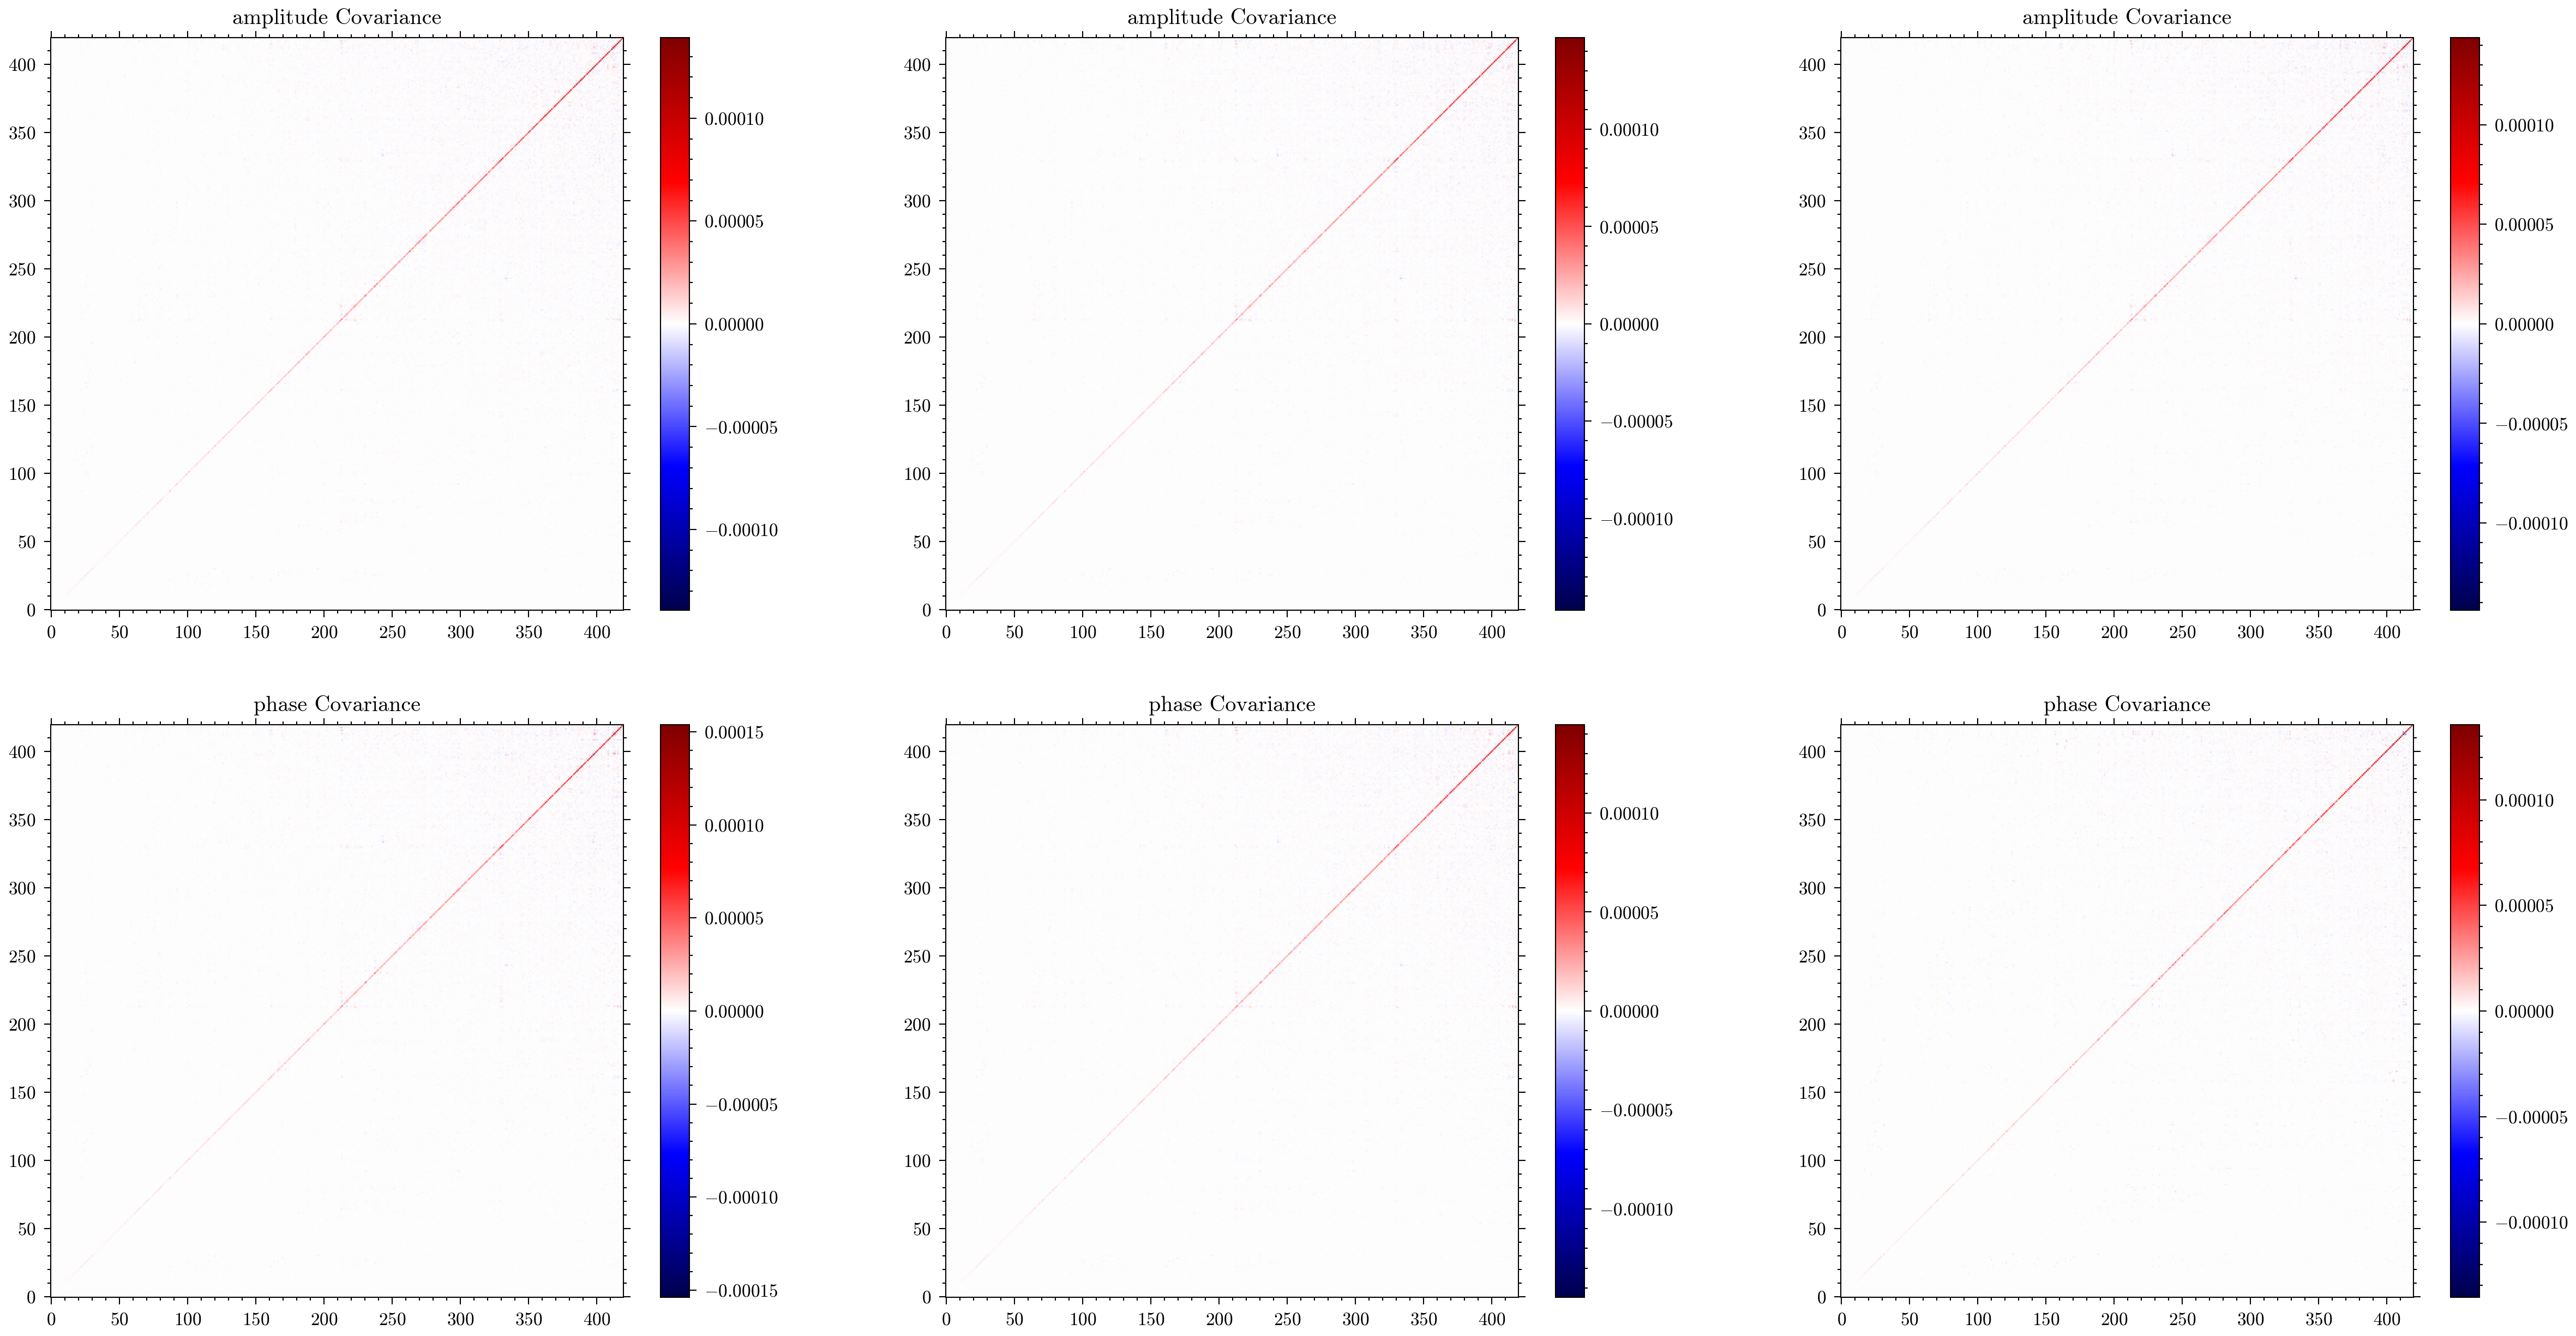

In [22]:
full_covs = jtu.map(lambda x: np.linalg.inv(x), fmats)

n = model.vis_model.n_basis
amp_covs = jtu.map(lambda x: x[:n, :n], full_covs)
phase_covs = jtu.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(20, 10))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = amp_covs[key]
    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    v = np.nanmax(np.abs(cov))
    plt.imshow(cov, seismic, vmin=-v, vmax=v)
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()

In [ ]:
fit_outputs = {
    "n_basis": final_model.vis_model.n_basis,
}

for exp in exposures:
    get_fn = lambda param: final_model.get(exp.map_param(param))
    fit_outputs[exp.key] = {
        "star": exp.star,
        "calibrator": exp.calibrator,
        "filter": exp.filter,
        "parang": exp.parang,
        "defocus": final_model.get(exp.map_param("defocus")),
        "n_basis": final_model.vis_model.n_basis,
        "fishers": fmats[exp.get_key("phases")],
        "amp_cov": amp_covs[exp.get_key("phases")],
        "phase_cov": phase_covs[exp.get_key("phases")],
        **{param: get_fn(param) for param in final_state.keys()},
    }

np.save(output_path + "visibilities_XO444", fit_outputs, allow_pickle=True)